# NODOSPLAZA

**Objetivos:**
1. Mapa de calor: temperatura y personas
2. Monitoreo de mascotas y personas
3. Monitoreo de uso y estado del mobiliario para decisiones municipales sobre un canil

**Modelos:**
**YOLOv8s** detecta personas, perros, gatos, bancas y sillas. Umbral de confianza por clase, zonas de exclusión para falsos positivos de objetos fijos. imgsz=1920 para mejor detección de objetos lejanos.
**BDRAR** genera máscara de sombra. Preentrenado, sin finetuning. Solo se aplica en condición diurna.
**Homografía (OpenCV)** proyecta píxeles de la cámara a metros reales y sobre imagen satelital. 9 puntos de control, error mediano 0.68 m.
**pythermalcomfort** calcula UTCI. tr se estima provisionalmente desde UV y sombra [REVISAR: reemplazar por modelo ERA5].
**KMeans** genera mapa de ocupación espacial en celdas de 2x2 m reales, y clustering temporal de regímenes de uso.

Hay **métricas** que se miden por snapshot (1 foto + data sensor de ese momento), y otras por batch (después de procesar varios snapshots):

Por snapshot:
**n personas y mascotas** (conteo actual)
**posición en metros** (homografía desde foot-point)
**shade utilization** (% personas/mascotas en sombra, medido sobre la cabeza)
**shade del parque** (% del suelo bajo el horizonte en sombra)
**ExG pasto** (índice de vegetación sobre zona de pasto, aproxima NDVI sin infrarrojo)
**uso mobiliario** (ocupado/libre por distancia real <=1.5 m, no por solape en perspectiva)
**UTCI** (índice de confort térmico, escala oficial de 10 categorías)
**densidad** (personas / área observada real en m², no área total del parque)
**aglomeración** (densidad > 0.13 p/m², estándar caniles AKC)

Por batch:
**presencia continua** (máxima racha de snapshots con personas, NO es dwell time individual)
**activity classification** (reposo/circulando por desplazamiento real en metros entre snapshots, guard: solo activo si intervalo <=15 seg)
**uso mobiliario histórico** (tasa de uso y demanda alta/normal/sin uso por mueble)
**shade histórico** (evolución temporal del shade personas y mascotas en bins de 5 min)
**vegetación temporal** (evolución del ExG diario para detectar secado del pasto, guard: requiere >=2 días)
**correlaciones** (Pearson entre métricas meteorológicas y de uso, guard: solo datos reales)
**grilla de ocupación** (mapa de dónde se para la gente en celdas 2x2 m sobre imagen satelital)
**kmeans temporal** (regímenes de uso del parque, guard: requiere >=100 snapshots reales)

Pipeline tareas de este nb:
- fase 0.5: cargar imagen desde disco (frame local, carpeta de batch o livestream)
- fase 1: yolo, detectar personas, mascotas y mobiliario. canvas de densidad sobre el frame (solo visual, en perspectiva)
- fase 1.5: homografía, proyectar detecciones a metros reales y sobre imagen satelital. calcular área observada. vista integrada cámara + mapa
- fase 2: bdrar, condición de luz, máscara de sombra, shade por personas/mascotas/parque sobre máscara de suelo (bajo horizonte y=260)
- fase 2.5: vegetación, índice ExG sobre polígonos de zona de pasto
- fase 3: uso mobiliario, ocupación por distancia real en metros (resuelve el problema de perspectiva)
- fase 3.5: consolidar data, unir outputs de todas las fases + sensores en snapshot_record. validar rangos físicos
- fase 4: pythermalcomfort, estimar tr y calcular UTCI con escala oficial de 10 categorías
- fase 5: aglomeración, densidad real sobre área observada (homografía)
- fase 5.5: guardar en csv, deduplicación por timestamp. la demo del snapshot individual no persiste
- fase 6: batch, procesar_snapshot() encapsula fases 1-5. submuestrea frames por timestamp real. calcula métricas históricas
- fase 7: kmeans, grilla espacial activa (celdas 2x2 m sobre satelital) + clustering temporal dormido
- tests: 24 asserts de invariantes, red de seguridad para el refactor

In [30]:
# %pip install ultralytics opencv-python numpy matplotlib pythermalcomfort scikit-learn torch torchvision scipy requests pillow pandas seaborn gdown

#### FASE 0.5: insertar imágenes de cámara

In [31]:
# NOTACIÓN DE COMENTARIOS — NODOSPLAZA
#
# [RECALIBRAR-CAM]      → recalibrar el día de instalación de la cámara en el Canil
# [RECALIBRAR-DATOS]    → calibrar con ground truth (labelear ~15-50 imágenes reales)
# [PENDIENTE-HOMOGRAFIA]→ no funciona correctamente hasta implementar homografía
# [DORMIDO]             → implementado pero no se activa hasta cumplir condición indicada
# [PROD]                → cambia al pasar a producción (RDS, servidor, credenciales)
# [AJUSTABLE]           → parámetro afinable sin urgencia ni dependencia externa
# [REVISAR]             → decisión de diseño pendiente de resolver, con contexto de qué

In [32]:
import sys
import os
import subprocess
import random
import json
import datetime
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
from PIL import Image
from io import BytesIO
import requests
import torch
import torch.nn as nn
from torchvision import transforms
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pythermalcomfort.models import utci
from ultralytics import YOLO
import warnings
import glob
import joblib
warnings.filterwarnings('ignore')

In [ ]:
# Imagen: debe coincidir con lo que manda la RPi [RECALIBRAR-CAM] confirmar resolución exacta una vez instalada
ANCHO = 1280
ALTO  = 720

# YOLO
CLASES_INTERES = {
    0:  'persona',
    13: 'banca',
    15: 'gato',
    16: 'perro',
    56: 'silla',
    # [RECALIBRAR-CAM] agregar clases custom tras fine-tuning con datos del Canil: rampa, túnel, piscina, bebedero, dispensador de bolsas
}

# [RECALIBRAR-DATOS] valores PROVISIONALES puestos al ojo, sin calibrar. Se ajustan
# con el labeling (barrido + ground truth), y se REHACEN por cada dataset (Cinquez
# centro/oeste/este → Canil). No tomar estas cifras como definitivas.
UMBRAL_CONFIANZA_POR_CLASE = {
    'persona': 0.40,   # más alto: personas son fáciles, evita falsos positivos
    'perro':   0.15,   # más bajo: mascotas chicas/lejanas, prioriza no perderlas
    'gato':    0.70,
    'banca':   0.30,   
    'silla':   0.30,
}
UMBRAL_CONFIANZA_MIN = min(UMBRAL_CONFIANZA_POR_CLASE.values())  

YOLO_IMGSZ = 1920 # [AJUSTABLE] resolución de inferencia. 1920 detecta bastante mejor objetos chicos (perros lejanos, cámara alta) que 1280. Costo: más lento y más RAM.
# [PROD] en RPi/servidor puede ser muy pesado — evaluar 1280 vs 1920 según el hardware.

# ── FASE 1.5: Homografía  ─────────────────────────────
# Puntos de control: (pixel_x, pixel_y, lat, lon) marcados a mano cruzando el frame con Google Maps satelital.
# [RECALIBRAR-CAM] estos puntos son de la center cam de Cinquez (práctica). El día de instalación se rehacen con el frame real del Canil y sus puntos de control.
PUNTOS_CONTROL_HOMOGRAFIA = [
    # (px,  py,   lat,        lon)
    (221,  491,  26.935343, -80.127945),
    (875,  407,  26.935401, -80.127830),
    (1154, 429,  26.935377, -80.127789),
    (360,  270,  26.935831, -80.128015),
    (849,  317,  26.935624, -80.127774),
    (1206, 299,  26.935699, -80.127563),
    (1217, 390,  26.935428, -80.127742),
    (960,  317,  26.935621, -80.127722),
    (531,  274,  26.935852, -80.127911),
]
# [RECALIBRAR-CAM] rehacer con satelital del Canil en instalación.
RUTA_SATELITAL = '../mapa_conimg.png'
PUNTOS_CONTROL_SATELITAL = [
    (817, 415, 26.935343, -80.127945),  # árbol
    (867, 385, 26.935401, -80.127830),  # esq inf izq techo cerca
    (888, 397, 26.935377, -80.127789),  # esq inf der techo cerca
    (782, 160, 26.935831, -80.128015),  # basurero
    (895, 269, 26.935624, -80.127774),  # banca
    (996, 228, 26.935699, -80.127563),  # esq inf der techo lejos
    (910, 371, 26.935428, -80.127742),  # esq sup der área techo cerca
    (920, 270, 26.935621, -80.127722),  # esquina área bancas
    (830, 148, 26.935852, -80.127911),  # poste
]

DISTANCIA_MAX_CONFIABLE_M = 40
# [AJUSTABLE] más allá de esta distancia la proyección no es confiable: cerca del
# horizonte unos pocos píxeles de error en el bbox equivalen a muchos metros.
# Las detecciones más lejanas se marcan pos_m=None y no entran a métricas espaciales.

# ── FASE 2: Sombra (BDRAR) y condición de luz ───────────────────────────────
# [RECALIBRAR-DATOS] marcar sombra a mano en 10-15 frames, medir IoU a distintos umbrales (0.3, 0.4, 0.5, 0.6), elegir el mejor. Repetir en instalación.
UMBRAL_BINARIZACION_SOMBRA = 0.5

# la literatura de confort indica que la carga radiante sobre la cabeza es la determinante. Ver persona_en_sombra().
# [RECALIBRAR-DATOS] afinar con ground truth; con región de cabeza el umbral es casi binario (cabeza al sol o a la sombra), así que importa menos.
UMBRAL_SOMBRA_CABEZA = 0.5
FRAC_CABEZA = 0.33  # tercio superior del bbox se considera "cabeza/hombros"

# Condición de luz
# Umbrales de lux (fuente primaria, cuando haya sensor real):
UMBRAL_LUX_DIURNO  = 10000  # [RECALIBRAR-DATOS] validar con TEMT6000 real y Maipú
UMBRAL_LUX_NUBLADO = 1000   # [RECALIBRAR-DATOS] idem
# Umbrales de respaldo desde la imagen (HSV), mientras no haya sensor de lux:
UMBRAL_BRILLO_NOCHE = 110   # [AJUSTABLE] brillo medio bajo esto → noche
UMBRAL_SAT_NUBLADO  = 75    # [AJUSTABLE] saturación media bajo esto → nublado

# [RECALIBRAR-CAM] la línea del horizonte cambia con el ángulo de la cámara del Canil.
HORIZONTE_SUELO_Y = 260  # [RECALIBRAR-CAM] fila de píxel donde empieza el suelo

# ── FASE 2.5: Vegetación — índice ExG sobre zona de pasto ────────────────────
# Polígonos de zona de PASTO (excluyen caminos, cemento) — para índice de vegetación.
# Marcados con image-map.net sobre 20260530_131329.jpg. Solo pasto, no senderos.
# [RECALIBRAR-CAM] redibujar sobre frame real del Canil.
ZONAS_PASTO = {
    'front': [(3,718),(3,327),(102,315),(138,314),(848,353),(766,401),
              (1228,449),(1224,387),(1167,384),(1171,372),(1278,374),(1277,718)],
    'der':   [(1278,348),(1277,303),(1190,302),(1184,316),(964,309),(942,334)],
    'izq':   [(794,317),(860,287),(124,267),(68,280),(137,289)],
}

# Zona de CONTROL: bajo tráfico, para comparar contra la zona de uso en el
# mismo instante (documento 02, decisión final sobre vegetación — reemplaza
# el enfoque semana-a-semana original). Debe ser pasto real, mismo tipo de
# superficie, pero fuera de donde la gente/mascotas circulan habitualmente.
# [RECALIBRAR-CAM] zona de Cinquez (práctica) — remarcar en el Canil.
ZONA_CONTROL_PASTO = {
    'control': [(370, 630), (516, 630), (516, 689), (370, 689)],
}

# Índice de vegetación: se usa ExG (Excess Green) = 2*G - R - B (normalizado).
# Aproxima NDVI usando solo RGB (sin infrarrojo). Fuente: Woebbecke et al. 1995
# Enfoque temporal (#Tarea3): en vez de umbral absoluto verde/seco, se guarda el
# ExG promedio por snapshot y se compara su EVOLUCIÓN día a día (el pasto secándose
# se ve como ExG bajando en el tiempo). Más robusto que un umbral fijo.
# [AJUSTABLE] umbral solo para clasificación gruesa opcional, no crítico con enfoque temporal.
UMBRAL_EXG_VERDE = 0.15  # [AJUSTABLE] ExG normalizado sobre esto → píxel "verde sano"


# ── FASE 3: Uso de mobiliario ────────────────────────────────────────────────

# Polígonos del mobiliario marcados sobre la SATELITAL (píxeles de mapa_conimg.png).
# [RECALIBRAR-CAM] remarcar sobre satelital del Canil en instalación.
MOBILIARIO_SATELITAL = {
    'banca_1': [(882,386),(890,391),(888,395),(879,390)],
    'banca_2': [(870,380),(868,383),(875,388),(877,385)],
    'banca_3': [(899,259),(892,266),(896,269),(902,262)],
    'banca_4': [(889,385),(892,387),(895,376),(899,378)],
    'banca_5': [(872,376),(876,379),(883,369),(879,366)],
}

# Radio de uso: persona a menos de esta distancia (metros reales) del centro del mueble = lo está usando.
RADIO_USO_MOBILIARIO_M = 1.5  # [AJUSTABLE]

# BBoxes en píxeles de cámara — se conservan SOLO para visualización sobre el frame. La lógica de ocupación ya NO los usa (usa MOBILIARIO_SATELITAL en metros).
MOBILIARIO_BBOXES = {
    'banca_1': (1038, 370, 1141, 426),
    'banca_2': (896,  360,  991, 413),
    'banca_3': (839,  293,  865, 319),
    'banca_4': (1100, 350, 1141, 380),
    'banca_5': (920,  330,  970, 370),
}

# ── FASE 3.5: Consolidación y sensores ───────────────────────────────────────

# Rangos de simulación de sensores (mientras no haya sensores reales)
# [PROD] por ahora valores representativos de verano en Maipú. En producción vienen del POST y datos_sinteticos pasa a False.
SIM_TDB = (18.0, 36.0)   # temperatura aire °C
SIM_RH  = (25.0, 80.0)   # humedad relativa %
SIM_V   = (0.0,  5.0)    # velocidad viento m/s
SIM_UV  = (0.0, 11.0)    # índice UV
SIM_LUX = (500, 80000)   # luz ambiental lux

# Horario operacional del parque.
# NOTA: hoy solo se GUARDA el flag hora_operacional en el snapshot, ninguna métrica
# filtra por él. Sirve para poder filtrar después (ej. excluir madrugadas del análisis).
# [REVISAR] decidir si las métricas de batch deberían considerar solo horario operacional.
HORA_APERTURA = 8   # [AJUSTABLE]
HORA_CIERRE   = 20  # [AJUSTABLE]

# Rangos físicos válidos de sensores, para marcar snapshot_valido (#16)
RANGO_VALIDO_TDB = (-20, 55)   # °C plausibles
RANGO_VALIDO_RH  = (0, 100)    # %
RANGO_VALIDO_V   = (0, 40)     # m/s

# ── FASE 4: UTCI ──────────────────────────────────────────────────────────────

# ── FASE 4: UTCI — modelo ERA5 (#18) ─────────────────────────────────────
# Carga de artefactos UNA SOLA VEZ (no por snapshot), mismo patrón que YOLO/BDRAR.
MODELO_MRT   = joblib.load('modelo_era5_mrt.pkl')
SCALER_MRT   = joblib.load('modelo_era5_scaler.pkl')
METADATA_MRT = joblib.load('modelo_era5_metadata.pkl')
VIENTO_CLIMA = joblib.load('modelo_era5_viento_climatologico.pkl')

FEATURES_MODELO_MRT = METADATA_MRT['features']  # orden exacto del entrenamiento
LAT_MODELO = METADATA_MRT['lat']          # -33.51, Maipú — la ubicación con la
LON_MODELO = METADATA_MRT['lon']          # que se entrenó, no la del frame de prueba
UTC_OFFSET_MODELO = METADATA_MRT['utc_offset']

# Cortes oficiales de la escala UTCI (°C) — estándar internacional, permanente.
# Fuente: Bröde et al. / Climate-ADAPT. 10 categorías de estrés térmico.
UTCI_CORTES = [
    (46,   'estrés térmico extremo'),
    (38,   'estrés térmico muy fuerte'),
    (32,   'estrés térmico fuerte'),
    (26,   'estrés térmico moderado'),
    (9,    'sin estrés térmico'),          # confortable: 9 a 26
    (0,    'leve estrés por frío'),
    (-13,  'estrés por frío moderado'),
    (-27,  'estrés por frío fuerte'),
    (-40,  'estrés por frío muy fuerte'),
    (-999, 'estrés por frío extremo'),
]

# Rangos de validez de pythermalcomfort para UTCI (#20)
UTCI_RANGO_V = (0.5, 17.0)   # m/s: viento fuera de esto → UTCI puede dar NaN

# ── FASE 5.5: Persistencia ────────────────────────────────────────────────────

RUTA_CSV = 'snapshots.csv'
# [PROD] reemplazar por PostgreSQL/RDS cuando el servidor esté levantado.
# [PROD] #24: CSV con JSON en celdas es frágil (comas anidadas). Mitigado con
# QUOTE_ALL. Migrar a JSONB en Postgres da robustez real.

# Columnas del CSV — deben coincidir con las claves del snapshot_record
HEADERS = [
    'timestamp', 'tdb', 'rh', 'v', 'uv', 'lux',
    'datos_sinteticos',
    'condicion_luz', 'hora_operacional', 'shade_confiable',
    'snapshot_valido', 'motivos_invalido',
    'n_personas', 'n_mascotas',
    'pies_personas', 'pies_mascotas',
    'pos_m_personas', 'pos_m_mascotas',                    # ← NUEVO: posiciones en metros (homografía)
    'shade_util_personas', 'shade_util_mascotas',
    'shade_parque_pct',
    'uso_mobiliario',
    'exg_pasto_prom',
    'exg_control', 'diferencia_exg',              # ← NUEVO: comparación espacial (#Tarea3)
    'utci_valor', 'utci_categoria', 'tr_estimada',                                       # ← NUEVO: índice vegetación (#Tarea3)
    'viento_usado', 'viento_es_real', 'utci_viento_estimado',  # ← NUEVO (#18)
    'densidad', 'aglomeracion', 'densidad_confiable',
    'area_observada_m2',                                    # ← NUEVO: área real vista por cámara (#21)
]

# ── FASE 6: Batch analytics ───────────────────────────────────────────────────

# Guard de framerate para activity classification (#25)
# Tracking serio usa >=1 fps (WILDTRACK usa 2 fps = 0.5s entre frames).
UMBRAL_INTERVALO_ACTIVITY_SEG = 0.5  # [AJUSTABLE]


# #26 RESUELTO con homografía: umbral de movimiento en METROS reales, no píxeles.
# Antes 50px era inconsistente (50px cerca ≠ 50px lejos en perspectiva).
# 1 m entre snapshots ≈ persona que se desplazó de verdad vs ajuste de postura.
UMBRAL_MOVIMIENTO_M = 1.0  # [AJUSTABLE] desplazamiento real sobre esto → circulando

# Umbral de "alta demanda" de un mueble (fracción del tiempo ocupado) — batch
UMBRAL_ALTA_DEMANDA = 0.3  # [AJUSTABLE] sobre esta tasa de uso → alta demanda

# Análisis temporal del pasto: compara el ExG promedio diario contra días previos.
VENTANA_VEGETACION_DIAS = 7   # [AJUSTABLE] ventana para promediar y comparar
UMBRAL_CAIDA_EXG = 0.10       # [AJUSTABLE] caída relativa que activa alerta "pasto secándose"
# [DORMIDO] requiere al menos VENTANA_VEGETACION_DIAS de datos reales acumulados.

# ── FASE 7: KMeans / clustering ───────────────────────────────────────────────

# Escenario 2 (temporal): mínimo de snapshots reales para clusters con sentido
KMEANS_N_MINIMO = 100   # [AJUSTABLE] menos que esto → dormido (clusters sin sentido)
KMEANS_N_CLUSTERS_TEMPORAL = 3  # [AJUSTABLE] regímenes de uso (ej. bajo/medio/alto)

# Escenario 1 (grilla espacial): 
KMEANS_TAM_CELDA_M = 2   # [AJUSTABLE] tamaño de celda de la grilla espacial, en metros




# Zonas donde NUNCA hay personas/mascotas, pero YOLO da falsos positivos.
# Objetos fijos (basureros, postes, señalética) que confunde con personas lejanas.
# Se descarta cualquier detección cuyo foot-point caiga dentro.
# [RECALIBRAR-CAM] identificar las zonas problemáticas del Canil tras instalar.
ZONAS_EXCLUSION = {
    'basurero_quincho': (1120, 330, 1155, 375),   # (x1,y1,x2,y2) conf~0.46 como persona
}

# Colores visualización (BGR)
COLOR_PERSONA            = (0, 255, 0)    # verde
COLOR_MASCOTA            = (0, 165, 255)  # naranja
COLOR_MOBILIARIO_LIBRE   = (255, 200, 0)  # azul claro
COLOR_MOBILIARIO_OCUPADO = (0, 0, 255)    # rojo

# Parque
AREA_PARQUE_M2 = 3000
# [RECALIBRAR-CAM] valor inventado. Verificar con plano municipal del Canil.

# Umbral aglomeración
UMBRAL_AGLOMERACION = 0.13
# Justificación: estándar de diseño de caniles → 75-100 ft²/perro en pico
# = ~7-9 m²/usuario → 0.11-0.14 usuarios/m². Se usa 0.13 (punto medio).
# Fuente: dog park design standards (AKC, Outdoor Workout Supply, Wagbar).
# [RECALIBRAR-DATOS] validar contra observación real en el Canil.

print(f'   Resolución: {ANCHO}×{ALTO}')
print(f'   Clases de interés: {list(CLASES_INTERES.values())}')
print(f'   Umbral aglomeración: {UMBRAL_AGLOMERACION} usuarios/m²')

   Resolución: 1280×720
   Clases de interés: ['persona', 'banca', 'gato', 'perro', 'silla']
   Umbral aglomeración: 0.13 usuarios/m²


In [34]:
def cargar_imagen_local(ruta):
    """Carga una imagen desde disco. Advierte si no coincide con la resolución esperada."""
    img = cv2.imread(ruta)
    if img is None:
        raise FileNotFoundError(f'No se encontró imagen en: {ruta}')
    # [RECALIBRAR-CAM] la RPi debería mandar exactamente ANCHO×ALTO. Mientras se
    # trabaja con livestreams de otras resoluciones, se redimensiona pero se avisa,
    # para no deformar en silencio si algún día llega algo inesperado (ver #1).
    h, w = img.shape[:2]
    if (w, h) != (ANCHO, ALTO):
        print(f'   [aviso] imagen {w}×{h} ≠ {ANCHO}×{ALTO} esperado, redimensionando')
        img = cv2.resize(img, (ANCHO, ALTO))
    return img


def mostrar_imagen(img_bgr, titulo='Imagen'):
    """Muestra una imagen BGR en el notebook."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 8))
    plt.imshow(img_rgb)
    plt.title(titulo, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

✅ 18704 frames disponibles en ../frames_cinquez_20260530/


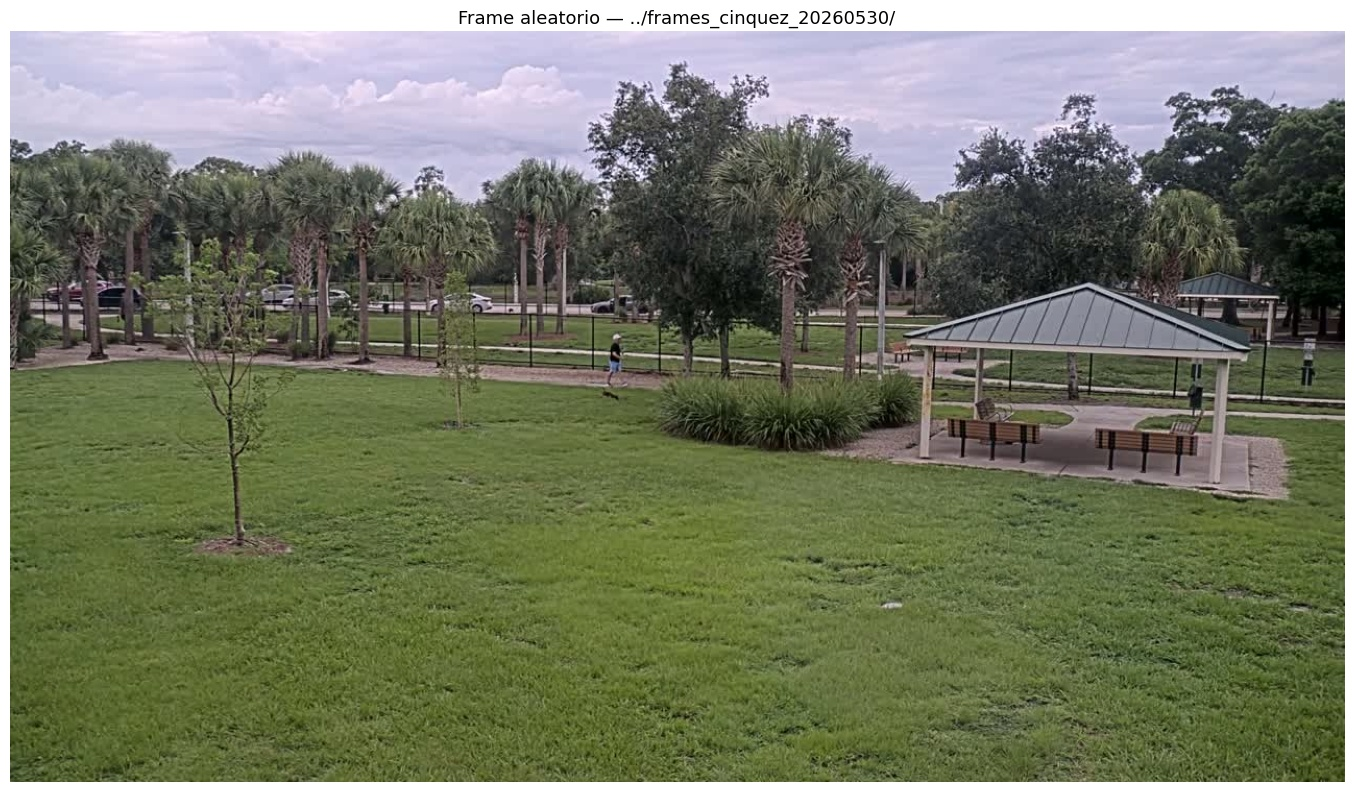

In [35]:
# [AJUSTABLE] fuente de frames de prueba. Opciones:
#   'frames_schuylkill/'         → video ~20 min, parque chico, MUCHA afluencia
#   'frames_cinquez_20260530/'   → livestream capturado, parque amplio, POCA afluencia
# Cinquez se parece más al Canil (amplio, poca gente); Schuylkill estresa el conteo.
CARPETA_FRAMES = '../frames_cinquez_20260530/'

# Andamiaje de desarrollo: en producción la imagen llega por el HTTP POST de la RPi,
# no se carga desde disco ni se elige al azar.
frames_disponibles = sorted(glob.glob(f'{CARPETA_FRAMES}*.jpg'))
if not frames_disponibles:
    raise FileNotFoundError(f'No hay frames .jpg en {CARPETA_FRAMES}')
print(f'✅ {len(frames_disponibles)} frames disponibles en {CARPETA_FRAMES}')

img_original = cargar_imagen_local(random.choice(frames_disponibles))
mostrar_imagen(img_original, f'Frame aleatorio — {CARPETA_FRAMES}')

#### FASE 1: YOLO

In [36]:
modelo_yolo = YOLO('yolov8s.pt')
# [RECALIBRAR-CAM] a futuro, fine-tuning con dataset propio del Canil para detectar
# mejor a la altura/ángulo real y agregar clases custom (rampa, bebedero, etc.)
print('Modelo YOLO cargado')

Modelo YOLO cargado


In [37]:
def correr_yolo(img_bgr, modelo, umbral_min=UMBRAL_CONFIANZA_MIN):
    result = modelo(
        img_bgr,
        conf         = umbral_min,
        iou          = 0.5,
        imgsz        = YOLO_IMGSZ,
        agnostic_nms = False,
        verbose      = False
    )[0]

    personas, mascotas, mobiliario = [], [], []
    for caja in result.boxes:
        clase_id = int(caja.cls)
        if clase_id not in CLASES_INTERES:
            continue
        clase = CLASES_INTERES[clase_id]
        conf  = round(float(caja.conf), 3)

        umbral_clase = UMBRAL_CONFIANZA_POR_CLASE.get(clase, umbral_min)
        if conf < umbral_clase:
            continue

        x1, y1, x2, y2 = map(int, caja.xyxy[0].tolist())
        pie = ((x1+x2)//2, y2)

        # #4: descartar falsos positivos conocidos — objetos fijos que YOLO confunde
        # con personas lejanas (ej. basurero detectado con conf~0.46). Como la cámara
        # es fija, basta excluir la región donde está el objeto.
        if clase in ('persona', 'perro', 'gato'):
            if any(ex[0] <= pie[0] <= ex[2] and ex[1] <= pie[1] <= ex[3]
                   for ex in ZONAS_EXCLUSION.values()):
                continue

        deteccion = {
            'clase': clase, 'confianza': conf,
            'bbox': (x1, y1, x2, y2),
            'pie': pie,
            'centro': ((x1+x2)//2, (y1+y2)//2),
        }
        if clase_id == 0:             personas.append(deteccion)
        elif clase_id in [15, 16]:    mascotas.append(deteccion)
        elif clase_id in [13, 56]:    mobiliario.append(deteccion)

    return {'personas': personas, 'mascotas': mascotas, 'mobiliario': mobiliario}


def generar_canvas(detecciones, categorias, alto, ancho):
    """Canvas gaussiano sobre el FRAME (perspectiva).
    #7: SOLO REFERENCIA VISUAL — el sigma en píxeles es inconsistente en perspectiva
    (40px cerca ≠ 40px lejos). Para análisis cuantitativo se usa
    generar_canvas_satelital() (Fase 1.5), que trabaja en el plano cenital."""
    canvas = np.zeros((alto, ancho), dtype=np.float32)
    for cat in categorias:
        for det in detecciones[cat]:
            cx, cy = det['pie']
            if 0 <= cx < ancho and 0 <= cy < alto:
                canvas[cy, cx] += 1.0
    canvas = gaussian_filter(canvas, sigma=40)  # [AJUSTABLE] solo estética
    if canvas.max() > 0:
        canvas /= canvas.max()
    return canvas

In [38]:
detecciones = correr_yolo(img_original, modelo_yolo)
print(f'personas:   {len(detecciones["personas"])}')
print(f'mascotas:   {len(detecciones["mascotas"])}')
print(f'mobiliario: {len(detecciones["mobiliario"])}')

# verificación #5: confirmar que las detecciones tienen foot-point
if detecciones['personas']:
    d = detecciones['personas'][0]
    print(f'  ej. persona → centro={d["centro"]}, pie={d["pie"]}')

personas:   1
mascotas:   0
mobiliario: 2
  ej. persona → centro=(579, 314), pie=(579, 340)


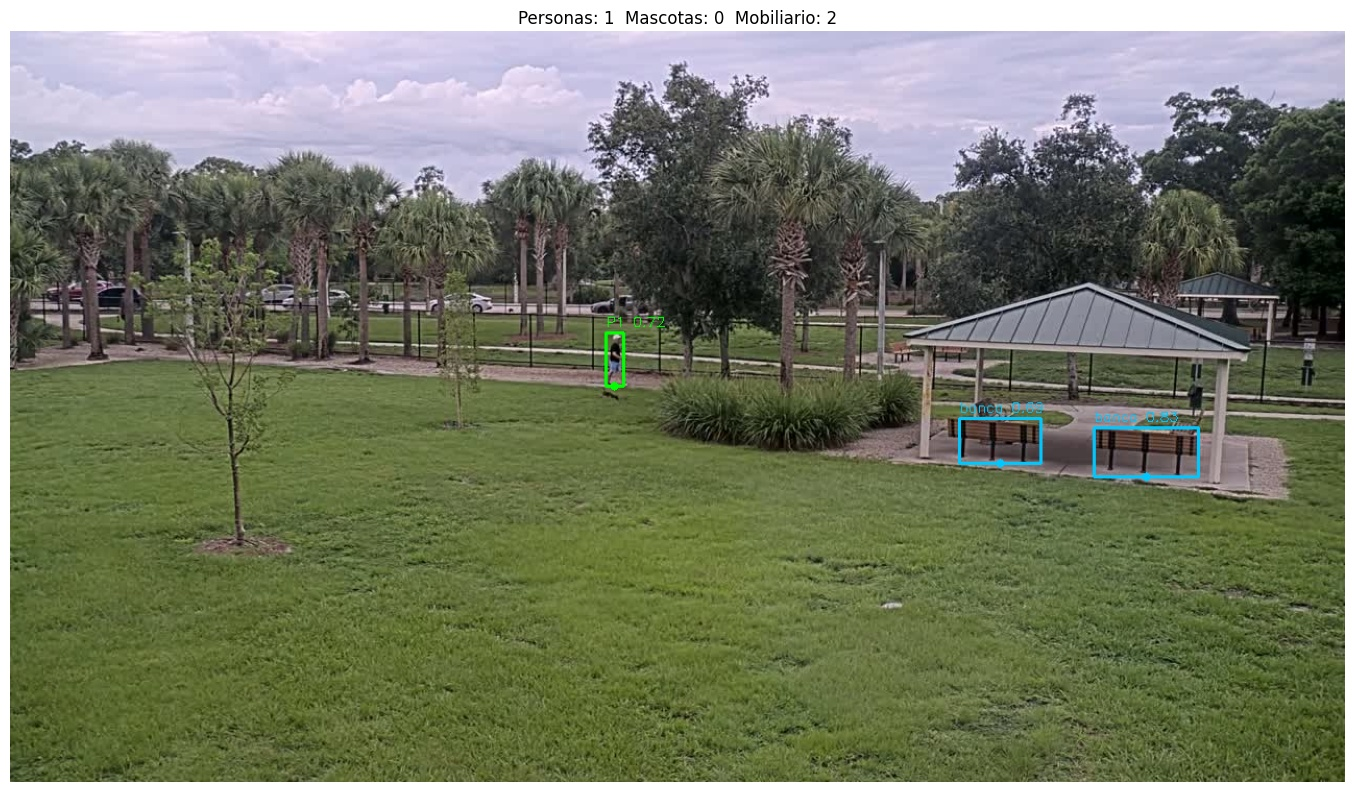

In [39]:
def visualizar_bboxes(img_bgr, detecciones):
    img_bboxes = img_bgr.copy()
    colores_categoria = {
        'personas':   COLOR_PERSONA,
        'mascotas':   COLOR_MASCOTA,
        'mobiliario': COLOR_MOBILIARIO_LIBRE,
    }
    for categoria, color in colores_categoria.items():
        for i, det in enumerate(detecciones[categoria]):
            x1, y1, x2, y2 = det['bbox']
            cv2.rectangle(img_bboxes, (x1, y1), (x2, y2), color, 2)
            # #5: marcar el foot-point (punto de contacto con el suelo)
            cv2.circle(img_bboxes, det['pie'], 4, color, -1)
            label = f"P{i+1} {det['confianza']:.2f}" if categoria == 'personas' \
                    else f"{det['clase']} {det['confianza']:.2f}"
            cv2.putText(img_bboxes, label, (x1, y1-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(img_bboxes, cv2.COLOR_BGR2RGB))
    plt.title(
        f'Personas: {len(detecciones["personas"])}  '
        f'Mascotas: {len(detecciones["mascotas"])}  '
        f'Mobiliario: {len(detecciones["mobiliario"])}', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualizar_bboxes(img_original, detecciones)

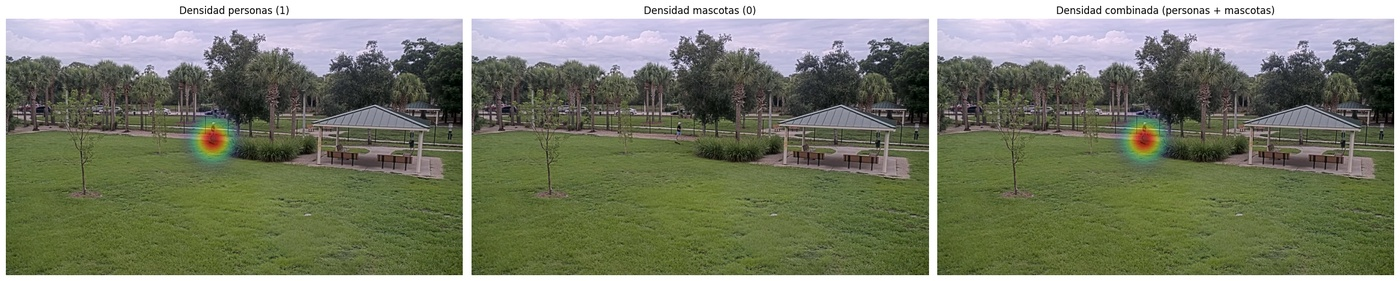

In [40]:
def superponer_heatmap(img_bgr, canvas):
    img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mask       = canvas[:, :, np.newaxis]
    resultado  = img_rgb * (1 - mask * 0.6) + plt.cm.jet(canvas)[:,:,:3] * (mask * 0.6)  # [AJUSTABLE] 0.6: opacidad
    return np.clip(resultado, 0, 1)

alto, ancho = img_original.shape[:2]

canvas_personas  = generar_canvas(detecciones, ['personas'],           alto, ancho)
canvas_mascotas  = generar_canvas(detecciones, ['mascotas'],           alto, ancho)
canvas_combinado = generar_canvas(detecciones, ['personas','mascotas'], alto, ancho)

fig, ejes = plt.subplots(1, 3, figsize=(24, 7))

ejes[0].imshow(superponer_heatmap(img_original, canvas_personas))
ejes[0].set_title(f'Densidad personas ({len(detecciones["personas"])})', fontsize=12)
ejes[0].axis('off')

ejes[1].imshow(superponer_heatmap(img_original, canvas_mascotas))
ejes[1].set_title(f'Densidad mascotas ({len(detecciones["mascotas"])})', fontsize=12)
ejes[1].axis('off')

ejes[2].imshow(superponer_heatmap(img_original, canvas_combinado))
ejes[2].set_title(f'Densidad combinada (personas + mascotas)', fontsize=12)
ejes[2].axis('off')

plt.tight_layout()
plt.show()

# guardar canvas combinado para reutilizar en Fase 5
canvas_heatmap = canvas_combinado

#### FASE 1.5 homografía

In [41]:
# ── Fase 1.5a: homografía cámara → metros ─────────────────────────────────────

def construir_homografia(puntos_control):
    """H (píxeles cámara → metros locales). Origen = primer punto. Retorna H y stats."""
    lat0, lon0 = puntos_control[0][2], puntos_control[0][3]
    m_lat = 111000
    m_lon = 111000 * np.cos(np.radians(lat0))
    pixeles, metros = [], []
    for px, py, lat, lon in puntos_control:
        pixeles.append([px, py])
        metros.append([(lon-lon0)*m_lon, (lat-lat0)*m_lat])
    pixeles = np.array(pixeles, dtype=np.float32)
    metros  = np.array(metros,  dtype=np.float32)
    H, mask = cv2.findHomography(pixeles, metros, cv2.RANSAC, 5.0)
    errores = []
    for px, mt in zip(pixeles, metros):
        p = np.array([[[px[0], px[1]]]], dtype=np.float32)
        proj = cv2.perspectiveTransform(p, H)[0][0]
        errores.append(np.sqrt((proj[0]-mt[0])**2 + (proj[1]-mt[1])**2))
    errores = np.array(errores)
    stats = {
        'n_inliers': int(mask.sum()), 'n_total': len(puntos_control),
        'error_medio': round(float(errores.mean()), 2),
        'error_mediano': round(float(np.median(errores)), 2),
        'origen_latlon': (lat0, lon0),
    }
    return H, stats

def proyectar_a_metros(punto_px, H):
    """Proyecta un punto (x,y) en píxeles a metros."""
    p = np.array([[[float(punto_px[0]), float(punto_px[1])]]], dtype=np.float32)
    m = cv2.perspectiveTransform(p, H)[0][0]
    return (round(float(m[0]), 2), round(float(m[1]), 2))

def proyectar_detecciones(detecciones, H):
    """Agrega pos_m (metros) desde el foot-point. Descarta proyecciones
    implausibles: cerca del horizonte el error se amplifica mucho."""
    for cat in ['personas', 'mascotas']:
        for d in detecciones[cat]:
            pos  = proyectar_a_metros(d['pie'], H)
            dist = (pos[0]**2 + pos[1]**2) ** 0.5
            confiable = dist <= DISTANCIA_MAX_CONFIABLE_M
            d['pos_m']           = pos if confiable else None
            d['pos_m_confiable'] = confiable
    return detecciones

H_HOMOGRAFIA, stats_homografia = construir_homografia(PUNTOS_CONTROL_HOMOGRAFIA)
detecciones = proyectar_detecciones(detecciones, H_HOMOGRAFIA)

print('=== HOMOGRAFÍA CÁMARA → METROS ===')
print(f'  Inliers: {stats_homografia["n_inliers"]}/{stats_homografia["n_total"]}')
print(f'  Error mediano: {stats_homografia["error_mediano"]} m')
if stats_homografia['error_mediano'] < 1.0:
    print('  ✅ precisión sub-métrica en la zona útil')

=== HOMOGRAFÍA CÁMARA → METROS ===
  Inliers: 8/9
  Error mediano: 0.68 m
  ✅ precisión sub-métrica en la zona útil


In [42]:
# ── Fase 1.5b: homografía metros → satelital ──────────────────────────────────

def construir_homografia_satelital(puntos_sat, lat0, lon0):
    """H que lleva METROS a píxeles de la imagen satelital."""
    m_lat = 111000
    m_lon = 111000 * np.cos(np.radians(lat0))
    metros, pix_sat = [], []
    for px, py, lat, lon in puntos_sat:
        metros.append([(lon-lon0)*m_lon, (lat-lat0)*m_lat])
        pix_sat.append([px, py])
    metros  = np.array(metros,  dtype=np.float32)
    pix_sat = np.array(pix_sat, dtype=np.float32)
    H, mask = cv2.findHomography(metros, pix_sat, cv2.RANSAC, 5.0)
    return H, int(mask.sum())

def metros_a_satelital(pos_m, H_m_sat):
    """Convierte posición en metros a píxel de la imagen satelital."""
    p = np.array([[[float(pos_m[0]), float(pos_m[1])]]], dtype=np.float32)
    s = cv2.perspectiveTransform(p, H_m_sat)[0][0]
    return (int(s[0]), int(s[1]))

lat0_h, lon0_h = stats_homografia['origen_latlon']
H_METROS_SAT, n_in_sat = construir_homografia_satelital(
    PUNTOS_CONTROL_SATELITAL, lat0_h, lon0_h)
print(f'Homografía metros→satelital: {n_in_sat}/{len(PUNTOS_CONTROL_SATELITAL)} inliers')

def generar_canvas_satelital(detecciones, categorias, H_m_sat, shape_sat, sigma_m=2.0):
    """#7 RESUELTO: canvas de densidad sobre el plano CENITAL (satelital).
    Sin distorsión de perspectiva → suavizado geográficamente uniforme.
    sigma_m se define en METROS y se convierte a píxeles de satelital."""
    alto_s, ancho_s = shape_sat[:2]
    canvas = np.zeros((alto_s, ancho_s), dtype=np.float32)

    for cat in categorias:
        for det in detecciones[cat]:
            if det.get('pos_m') is None:
                continue
            sx, sy = metros_a_satelital(det['pos_m'], H_m_sat)
            if 0 <= sx < ancho_s and 0 <= sy < alto_s:
                canvas[sy, sx] += 1.0

    # sigma de metros → píxeles de satelital: medir cuántos px equivale 1 m
    p0 = np.array(metros_a_satelital((0, 0), H_m_sat), dtype=float)
    p1 = np.array(metros_a_satelital((1, 0), H_m_sat), dtype=float)
    px_por_metro = np.linalg.norm(p1 - p0)

    canvas = gaussian_filter(canvas, sigma=sigma_m * px_por_metro)
    if canvas.max() > 0:
        canvas /= canvas.max()
    return canvas

def satelital_a_metros(pos_sat, H_m_sat):
    """Inversa: píxel de satelital → metros. Útil para convertir cosas marcadas
    sobre el mapa (mobiliario, zonas) a coordenadas reales."""
    H_inv = np.linalg.inv(H_m_sat)
    p = np.array([[[float(pos_sat[0]), float(pos_sat[1])]]], dtype=np.float32)
    m = cv2.perspectiveTransform(p, H_inv)[0][0]
    return (round(float(m[0]), 2), round(float(m[1]), 2))

MOBILIARIO_METROS = {}
for nombre, pts_sat in MOBILIARIO_SATELITAL.items():
    pts_m = [satelital_a_metros(p, H_METROS_SAT) for p in pts_sat]
    cx = round(float(np.mean([q[0] for q in pts_m])), 2)
    cy = round(float(np.mean([q[1] for q in pts_m])), 2)
    MOBILIARIO_METROS[nombre] = {'centro_m': (cx, cy), 'vertices_m': pts_m}

print('Mobiliario en metros reales:')
for nombre, d in MOBILIARIO_METROS.items():
    print(f'  {nombre}: centro {d["centro_m"]} m')
    
    # #21: área REALMENTE observada por la cámara, en m² — polígono del campo de visión
# proyectado al plano. La densidad debe dividirse por esto, NO por el área total
# del parque (la cámara no ve todo el parque).
def calcular_area_observada(H, ancho_px, alto_px, horizonte_y=HORIZONTE_SUELO_Y):
    """Área en m² del suelo visible: proyecta las 4 esquinas de la región bajo el
    horizonte y calcula el área del cuadrilátero resultante (fórmula del zapato)."""
    esquinas_px = [
        (0, horizonte_y), (ancho_px-1, horizonte_y),
        (ancho_px-1, alto_px-1), (0, alto_px-1),
    ]
    pts_m = [proyectar_a_metros(p, H) for p in esquinas_px]
    # fórmula del zapato (shoelace) para el área del polígono
    area = 0.0
    n = len(pts_m)
    for i in range(n):
        x1, y1 = pts_m[i]
        x2, y2 = pts_m[(i+1) % n]
        area += x1*y2 - x2*y1
    return round(abs(area) / 2, 1), pts_m

AREA_OBSERVADA_M2, esquinas_area_m = calcular_area_observada(H_HOMOGRAFIA, ANCHO, ALTO)
print(f'Área observada por la cámara: {AREA_OBSERVADA_M2} m²')
print(f'  (vs área total del parque declarada: {AREA_PARQUE_M2} m²)')

Homografía metros→satelital: 9/9 inliers
Mobiliario en metros reales:
  banca_1: centro (14.8, 5.25) m
  banca_2: centro (12.18, 6.67) m
  banca_3: centro (17.37, 32.23) m
  banca_4: centro (16.72, 7.2) m
  banca_5: centro (13.24, 9.15) m
Área observada por la cámara: 14814.1 m²
  (vs área total del parque declarada: 3000 m²)


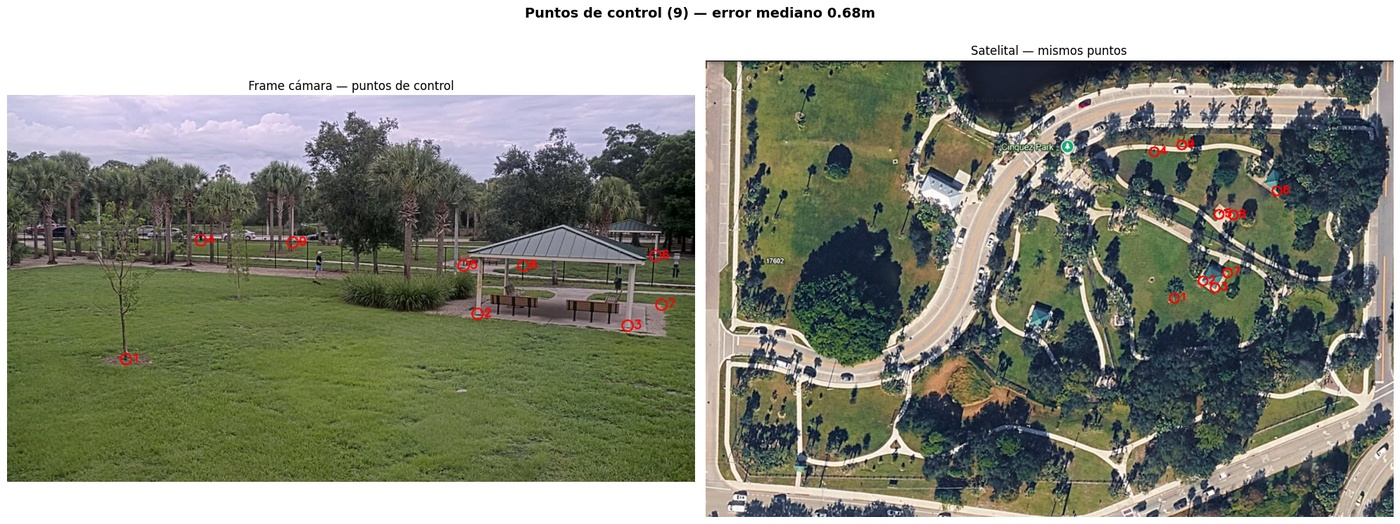

In [43]:
# ── Fase 1.5c: verificación visual de puntos de control ───────────────────────
frame_vis = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).copy()
sat_vis   = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()

for i, (pc, ps) in enumerate(zip(PUNTOS_CONTROL_HOMOGRAFIA, PUNTOS_CONTROL_SATELITAL)):
    n = i + 1
    cv2.circle(frame_vis, (pc[0], pc[1]), 10, (255, 0, 0), 2)
    cv2.putText(frame_vis, str(n), (pc[0]+12, pc[1]+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    cv2.circle(sat_vis, (ps[0], ps[1]), 8, (255, 0, 0), 2)
    cv2.putText(sat_vis, str(n), (ps[0]+10, ps[1]+4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.imshow(frame_vis); ax1.set_title('Frame cámara — puntos de control'); ax1.axis('off')
ax2.imshow(sat_vis);   ax2.set_title('Satelital — mismos puntos');        ax2.axis('off')
plt.suptitle(f'Puntos de control ({len(PUNTOS_CONTROL_HOMOGRAFIA)}) — '
             f'error mediano {stats_homografia["error_mediano"]}m',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

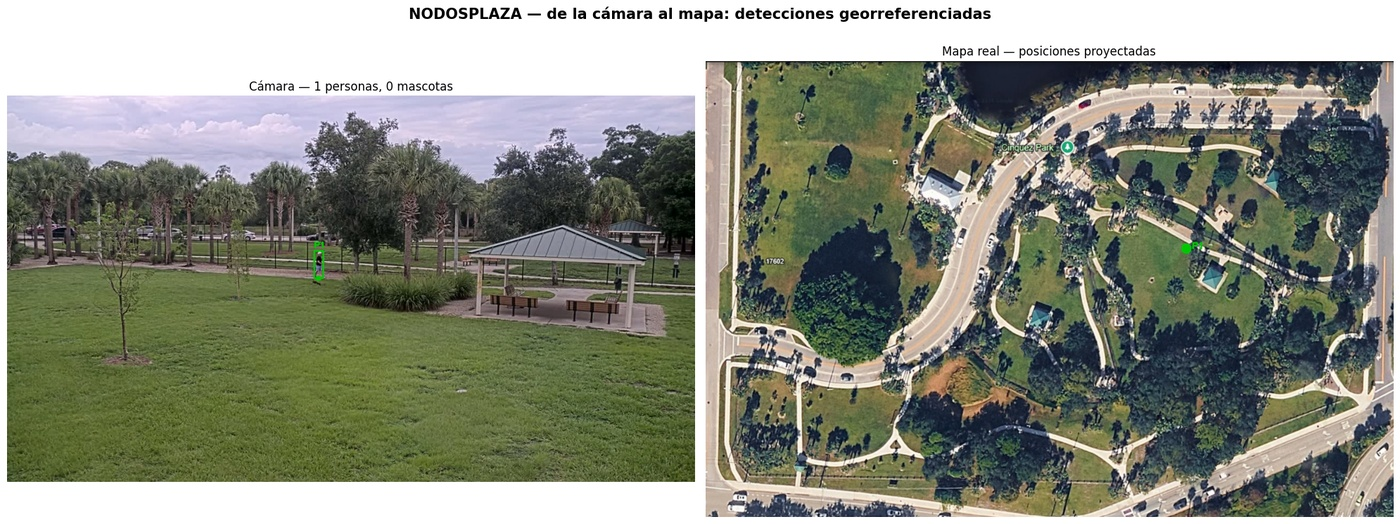

In [44]:
# ── Fase 1.5d: vista integrada — detecciones cámara + proyección satelital ────
frame_det = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).copy()
sat_det   = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()

for i, d in enumerate(detecciones['personas']):
    x1, y1, x2, y2 = d['bbox']
    cv2.rectangle(frame_det, (x1, y1), (x2, y2), (0, 200, 0), 2)
    cv2.circle(frame_det, d['pie'], 5, (0, 200, 0), -1)
    cv2.putText(frame_det, f'P{i+1}', (x1, y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,200,0), 2)
    sx, sy = metros_a_satelital(d['pos_m'], H_METROS_SAT)
    cv2.circle(sat_det, (sx, sy), 9, (0, 200, 0), -1)
    cv2.putText(sat_det, f'P{i+1}', (sx+10, sy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,200,0), 2)

for i, d in enumerate(detecciones['mascotas']):
    x1, y1, x2, y2 = d['bbox']
    cv2.rectangle(frame_det, (x1, y1), (x2, y2), (255, 140, 0), 2)
    cv2.circle(frame_det, d['pie'], 5, (255, 140, 0), -1)
    sx, sy = metros_a_satelital(d['pos_m'], H_METROS_SAT)
    cv2.circle(sat_det, (sx, sy), 9, (255, 140, 0), -1)
    cv2.putText(sat_det, f'M{i+1}', (sx+10, sy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,140,0), 2)

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.imshow(frame_det)
ax1.set_title(f'Cámara — {len(detecciones["personas"])} personas, {len(detecciones["mascotas"])} mascotas')
ax1.axis('off')
ax2.imshow(sat_det)
ax2.set_title('Mapa real — posiciones proyectadas')
ax2.axis('off')
plt.suptitle('NODOSPLAZA — de la cámara al mapa: detecciones georreferenciadas',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

#### FASE 2: BDRAR

In [45]:
# setup BDRAR : clonar repo y descargar pesos
# ATENCIÓN: pesos BDRAR (3000.pth) requieren descarga manual:
#   1. https://github.com/zijundeng/BDRAR ->  README -> "pretrained model" -> Google Drive
#   2. Descargar 3000.pth
#   3. Copiar a: Shadow-Detection-and-Removal/ckpt/BDRAR/3000.pth
# [PROD] en el servidor, versionar estos pesos junto al pipeline para no depender
# de la descarga manual en cada despliegue.

# clonar repo
if not os.path.exists('./Shadow-Detection-and-Removal'):
    subprocess.run(['git', 'clone',
                    'https://github.com/RolandGao/Shadow-Detection-and-Removal'],
                   check=True)

RUTA_BDRAR = os.path.abspath('./Shadow-Detection-and-Removal')

# descargar backbone ResNeXt101
ruta_resnext = os.path.join(RUTA_BDRAR, 'resnext', 'resnext_101_32x4d.pth')
if not os.path.exists(ruta_resnext):
    import gdown
    gdown.download(
        'https://drive.google.com/uc?id=1dnH-IHwmu9xFPlyndqI6MfF4LvH6JKNQ',
        ruta_resnext, quiet=False
    )

# parchar config.py con ruta absoluta del backbone
# necesario porque el repo tiene el path hardcodeado como ruta relativa
ruta_config = os.path.join(RUTA_BDRAR, 'resnext', 'config.py')
with open(ruta_config, 'w') as f:
    f.write(f"resnext_101_32_path = r'{ruta_resnext}'\n")
print(f'✅ config.py parcheado: {ruta_resnext}')

# verificar pesos BDRAR
ruta_bdrar_pesos = os.path.join(RUTA_BDRAR, 'ckpt', 'BDRAR', '3000.pth')
os.makedirs(os.path.dirname(ruta_bdrar_pesos), exist_ok=True)
if not os.path.exists(ruta_bdrar_pesos):
    print('⚠️  Pesos BDRAR no encontrados — descarga manual requerida')
    print(f'   → Copiar 3000.pth a: {ruta_bdrar_pesos}')

✅ config.py parcheado: c:\Users\ACER\Desktop\u\nodosplaza\v6\Shadow-Detection-and-Removal\resnext\resnext_101_32x4d.pth


In [46]:
# cargar modelo BDRAR
# se carga por ruta absoluta
import importlib.util
spec = importlib.util.spec_from_file_location('model', os.path.join(RUTA_BDRAR, 'model.py'))
modulo_model = importlib.util.module_from_spec(spec)
if RUTA_BDRAR not in sys.path:
    sys.path.insert(0, RUTA_BDRAR)
spec.loader.exec_module(modulo_model)

# si faltan los pesos, dejar modelo_bdrar = None y seguir sin sombra
# (el pipeline ya contempla este caso: noche/nublado/sin-BDRAR → máscara vacía)
if os.path.exists(ruta_bdrar_pesos):
    modelo_bdrar = modulo_model.BDRAR()
    modelo_bdrar.load_state_dict(torch.load(ruta_bdrar_pesos, map_location='cpu'))
    modelo_bdrar.eval()
    print(f'✅ BDRAR cargado. pesos: {ruta_bdrar_pesos}')
else:
    modelo_bdrar = None
    print('⚠️  BDRAR desactivado (sin pesos) — la detección de sombra se omitirá')

✅ BDRAR cargado. pesos: c:\Users\ACER\Desktop\u\nodosplaza\v6\Shadow-Detection-and-Removal\ckpt\BDRAR\3000.pth


In [47]:
# Una sola función decide día/noche/nublado:
#   - si hay lux REAL del sensor → lo usa (fuente física, confiable)
#   - si no (hoy, sin sensores)  → usa la imagen (HSV) como respaldo
# El día que llegue el sensor, se pasa lux_es_real=True y cambia de fuente sola.
def determinar_condicion_luz(img_bgr, lux=None, lux_es_real=False):
    """Fuente única de verdad para condición de luz → 'diurno' | 'nublado' | 'baja_luz'.
    Prioriza lux real; si no hay, cae a la imagen (HSV)."""
    if lux_es_real and lux is not None:
        if lux >= UMBRAL_LUX_DIURNO:    return 'diurno'
        elif lux >= UMBRAL_LUX_NUBLADO: return 'nublado'
        else:                           return 'baja_luz'
    else:
        hsv    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        brillo = float(hsv[:, :, 2].mean())
        sat    = float(hsv[:, :, 1].mean())
        if brillo < UMBRAL_BRILLO_NOCHE: return 'baja_luz'   # noche
        elif sat < UMBRAL_SAT_NUBLADO:   return 'nublado'
        else:                            return 'diurno'

# ── Máscara de suelo para shade_parque_pct (#8 RESUELTO) ─────────────────────
# La sombra que importa es la que cae sobre el suelo, no sobre cielo, árboles del
# fondo o techos. Como la cámara es fija, el horizonte del suelo está siempre en
# la misma fila de píxeles (y≈HORIZONTE_SUELO_Y): bajo esa línea es suelo.
# No hace falta un modelo de segmentación — basta el corte, porque la cámara no se mueve.
def construir_mascara_suelo(alto, ancho, horizonte_y=HORIZONTE_SUELO_Y):
    """Máscara binaria: 1 = suelo (bajo el horizonte), 0 = cielo/fondo."""
    mascara = np.zeros((alto, ancho), dtype=np.uint8)
    mascara[horizonte_y:, :] = 1
    return mascara

MASCARA_SUELO = construir_mascara_suelo(ALTO, ANCHO)
print(f'Máscara de suelo: {MASCARA_SUELO.sum()} px de suelo '
      f'({100*MASCARA_SUELO.mean():.1f}% de la imagen, horizonte en y={HORIZONTE_SUELO_Y})')

# ── Transform de BDRAR ──────────────────────────────────────────────────────
transformacion_bdrar = transforms.Compose([
    transforms.Resize((416, 416)),  # [AJUSTABLE] bajar a 256 si es lento
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def detectar_sombra(img_bgr, modelo):
    """Devuelve máscara binaria de sombra (1=sombra). #9: umbral fijo calibrable."""
    alto, ancho = img_bgr.shape[:2]
    x = transformacion_bdrar(Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))).unsqueeze(0)
    with torch.no_grad():
        pred = modelo(x).squeeze().cpu().numpy()
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    pred = cv2.resize(pred, (ancho, alto))
    return (pred > UMBRAL_BINARIZACION_SOMBRA).astype(np.uint8) 

Máscara de suelo: 588800 px de suelo (63.9% de la imagen, horizonte en y=260)


In [48]:
def region_en_sombra(bbox, mascara):
    """¿La CABEZA de la persona/mascota está en sombra? (#11)
    Mide sombra solo sobre el tercio superior del bbox (cabeza/hombros), porque
    la literatura de confort indica que la carga radiante sobre la cabeza es la
    determinante — no el cuerpo entero. Retorna (bool, pct_sombra_cabeza)."""
    x1, y1, x2, y2 = bbox
    alto_bbox = y2 - y1
    y_cabeza  = y1 + int(alto_bbox * FRAC_CABEZA)  # tercio superior
    region = mascara[y1:y_cabeza, x1:x2]
    if region.size == 0:
        return False, 0.0
    pct = float(np.mean(region))
    return pct > UMBRAL_SOMBRA_CABEZA, round(pct, 3)

In [49]:
# ejecutar BDRAR y cruzar con detecciones
condicion_luz = determinar_condicion_luz(img_original, lux=None, lux_es_real=False)

shade_util_personas = None
shade_util_mascotas = None
shade_parque_pct    = None

if condicion_luz != 'diurno':
    mascara_sombra = np.zeros((ALTO, ANCHO), dtype=np.uint8)
    print(f'{condicion_luz} — BDRAR omitido (sin sol confiable)')
elif modelo_bdrar is None:
    mascara_sombra = np.zeros((ALTO, ANCHO), dtype=np.uint8)
    print('BDRAR desactivado (sin pesos) — sombra omitida')
else:
    mascara_sombra = detectar_sombra(img_original, modelo_bdrar)
    for d in detecciones['personas'] + detecciones['mascotas']:
        d['en_sombra'], d['pct_sombra'] = region_en_sombra(d['bbox'], mascara_sombra)

    def _shade_util(lista):
        return round(sum(1 for d in lista if d['en_sombra']) / len(lista), 3) if lista else 0.0
    shade_util_personas = _shade_util(detecciones['personas'])
    shade_util_mascotas = _shade_util(detecciones['mascotas'])

    # #8 RESUELTO: % de sombra sobre el SUELO real (bajo el horizonte),
    # no sobre toda la imagen (que incluía cielo, árboles del fondo, techos).
    shade_parque_pct = round(float(np.mean(mascara_sombra[MASCARA_SUELO == 1])), 3)

    print(f'diurno — shade personas: {shade_util_personas}, '
          f'mascotas: {shade_util_mascotas}, suelo: {shade_parque_pct}')

diurno — shade personas: 0.0, mascotas: 0.0, suelo: 0.005


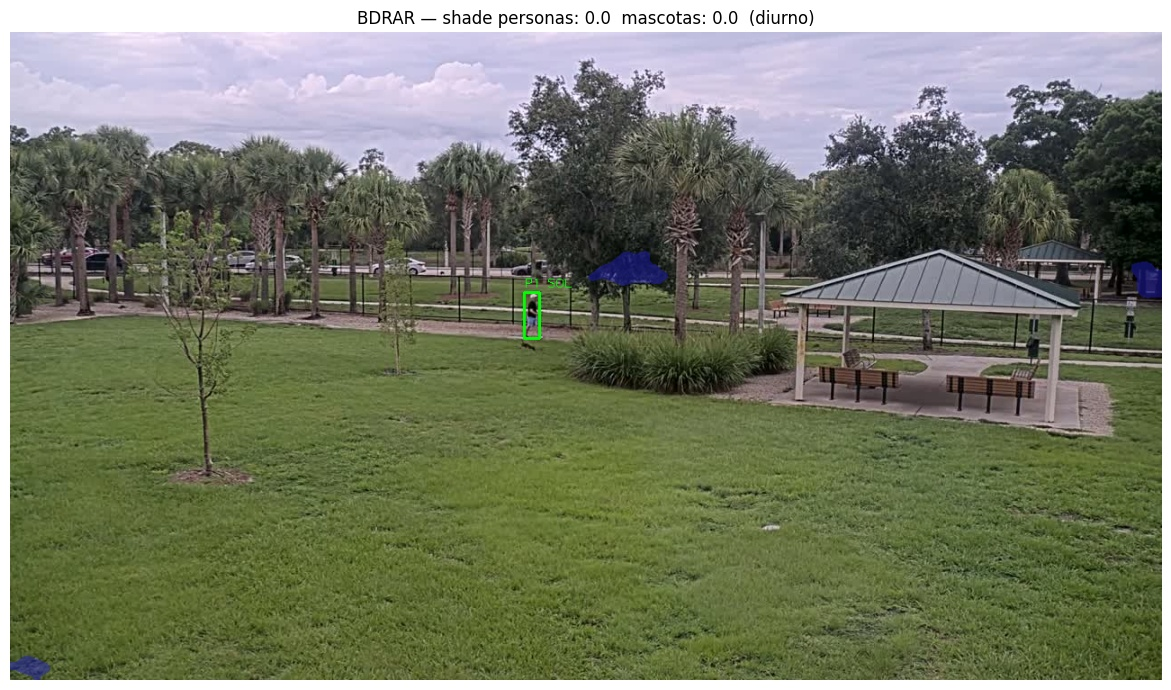

In [50]:
# visualización
overlay = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).astype(np.float32)
if condicion_luz == 'diurno' and modelo_bdrar is not None:
    overlay[mascara_sombra==1] = overlay[mascara_sombra==1]*0.5 + np.array([30,30,180])*0.5  # [AJUSTABLE] opacidad
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

for i, p in enumerate(detecciones['personas']):
    x1,y1,x2,y2 = p['bbox']
    cv2.rectangle(overlay,(x1,y1),(x2,y2),COLOR_PERSONA,2)
    cv2.putText(overlay,f'P{i+1} {"SOMBRA" if p.get("en_sombra") else "SOL"}',(x1,y1-6),cv2.FONT_HERSHEY_SIMPLEX,0.45,COLOR_PERSONA,1)
for m in detecciones['mascotas']:
    x1,y1,x2,y2 = m['bbox']
    color = (200,80,255) if m.get('en_sombra') else (0,140,255)
    cv2.rectangle(overlay,(x1,y1),(x2,y2),color,2)
    cv2.putText(overlay,f'{"SOMBRA" if m.get("en_sombra") else "SOL"}',(x1,y1-6),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1)

sp = f'{shade_util_personas}' if shade_util_personas is not None else 'N/A'
sm = f'{shade_util_mascotas}' if shade_util_mascotas is not None else 'N/A'
plt.close('all')
plt.figure(figsize=(14,7))
plt.imshow(overlay)
plt.title(f'BDRAR — shade personas: {sp}  mascotas: {sm}  ({condicion_luz})', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

#### fase 2.5: pasto

In [51]:
# ── FASE 2.5: Vegetación — índice ExG sobre zona de pasto ────────────────────
# Mide qué tan "verde/sano" está el pasto usando solo RGB (sin infrarrojo).
# ExG (Excess Green) = 2*G - R - B, normalizado. Alto = vegetación sana.
# Enfoque temporal: se guarda el promedio por snapshot; el batch compara su
# evolución día a día (pasto secándose = ExG bajando), no un umbral absoluto.

def construir_mascara_pasto(zonas_pasto, alto, ancho):
    """Máscara binaria (1 = pasto) desde los polígonos marcados. Solo pasto,
    excluye caminos y cemento — importante para no contaminar el índice."""
    mascara = np.zeros((alto, ancho), dtype=np.uint8)
    for nombre, pts in zonas_pasto.items():
        poligono = np.array(pts, dtype=np.int32)
        cv2.fillPoly(mascara, [poligono], 1)
    return mascara

MASCARA_PASTO = construir_mascara_pasto(ZONAS_PASTO, ALTO, ANCHO)
print(f'Máscara de pasto: {MASCARA_PASTO.sum()} px '
      f'({100*MASCARA_PASTO.mean():.1f}% de la imagen)')


def calcular_exg(img_bgr, mascara_pasto=None):
    """
    Índice ExG (Excess Green) normalizado, promediado sobre la zona de pasto.
    ExG = 2*g - r - b, con r,g,b normalizados (r = R/(R+G+B), etc.)
    Rango teórico: -1 a 2. Vegetación sana ~0.1-0.4; suelo/seco cerca de 0 o negativo.
    Retorna dict con el promedio y la fracción de píxeles sobre el umbral de verde.
    """
    img = img_bgr.astype(np.float32)
    B, G, R = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    suma = R + G + B + 1e-8            # evita división por cero
    r, g, b = R/suma, G/suma, B/suma
    exg = 2*g - r - b

    if mascara_pasto is not None:
        valores = exg[mascara_pasto == 1]
    else:
        valores = exg.flatten()

    if valores.size == 0:
        return {'exg_prom': None, 'frac_verde': None}

    return {
        'exg_prom':   round(float(valores.mean()), 4),
        'frac_verde': round(float((valores > UMBRAL_EXG_VERDE).mean()), 4),
    }

Máscara de pasto: 484852 px (52.6% de la imagen)


ExG promedio (zona pasto): 0.2405
Fracción de píxeles verdes: 0.9266


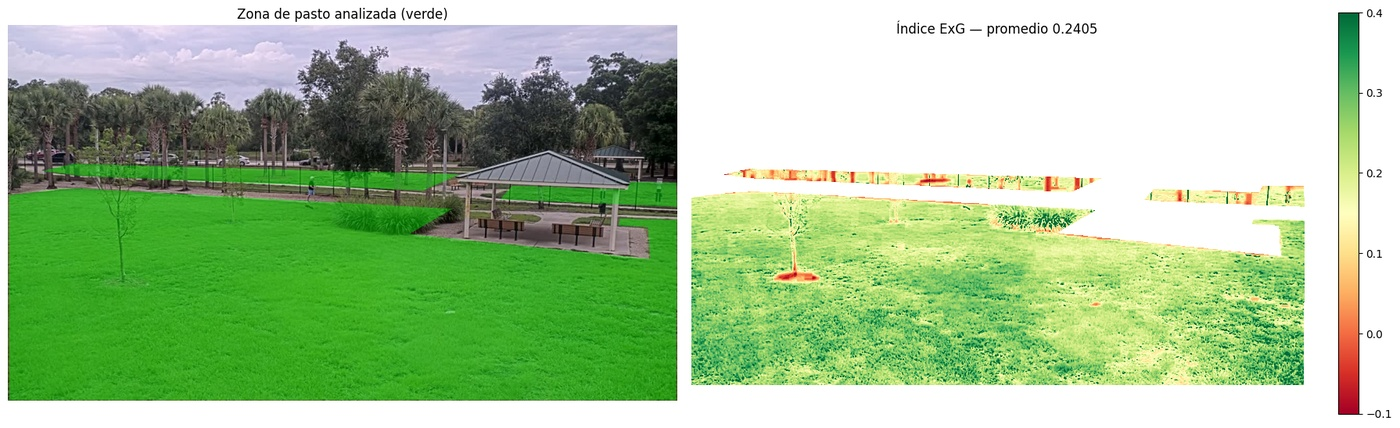

In [52]:
# ── Fase 2.5: verificar índice de vegetación ─────────────────────────────────
resultado_veg = calcular_exg(img_original, MASCARA_PASTO)
print(f'ExG promedio (zona pasto): {resultado_veg["exg_prom"]}')
print(f'Fracción de píxeles verdes: {resultado_veg["frac_verde"]}')

# visualización: máscara de pasto + mapa de ExG
img_f = img_original.astype(np.float32)
B, G, R = img_f[:,:,0], img_f[:,:,1], img_f[:,:,2]
suma = R+G+B+1e-8
exg_map = 2*(G/suma) - (R/suma) - (B/suma)

overlay = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).copy()
overlay[MASCARA_PASTO == 1] = (overlay[MASCARA_PASTO == 1]*0.6 +
                                np.array([0,255,0])*0.4).astype(np.uint8)

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.imshow(overlay)
ax1.set_title('Zona de pasto analizada (verde)')
ax1.axis('off')
im = ax2.imshow(np.where(MASCARA_PASTO==1, exg_map, np.nan), cmap='RdYlGn', vmin=-0.1, vmax=0.4)
ax2.set_title(f'Índice ExG — promedio {resultado_veg["exg_prom"]}')
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.03)
plt.tight_layout()
plt.show()

In [53]:
MASCARA_CONTROL = construir_mascara_pasto(ZONA_CONTROL_PASTO, ALTO, ANCHO)
print(f'Máscara de control: {MASCARA_CONTROL.sum()} px '
      f'({100*MASCARA_CONTROL.mean():.2f}% de la imagen)')


def comparar_vegetacion_uso_control(exg_uso, img_bgr, mascara_control):
    """
    Compara el ExG de la zona de uso (ya calculado sobre MASCARA_PASTO) contra
    la zona de control, en el mismo snapshot. Clima y estación afectan a ambas
    por igual, así que la diferencia aísla el efecto de uso real — sin guard,
    funciona desde el primer snapshot (documento 02).
    """
    control = calcular_exg(img_bgr, mascara_control)
    if exg_uso is None or control['exg_prom'] is None:
        return {'exg_control': None, 'diferencia_exg': None}
    return {
        'exg_control':    control['exg_prom'],
        'diferencia_exg': round(exg_uso - control['exg_prom'], 4),
        # negativo = zona de uso más seca/desgastada que la de control
    }

Máscara de control: 8820 px (0.96% de la imagen)


In [54]:
resultado_control = comparar_vegetacion_uso_control(
    resultado_veg['exg_prom'], img_original, MASCARA_CONTROL)
resultado_veg.update(resultado_control)
print(f'ExG zona de control:        {resultado_veg["exg_control"]}')
print(f'Diferencia (uso − control): {resultado_veg["diferencia_exg"]}')

ExG zona de control:        0.2833
Diferencia (uso − control): -0.0428


#### FASE 3: uso mobiliario

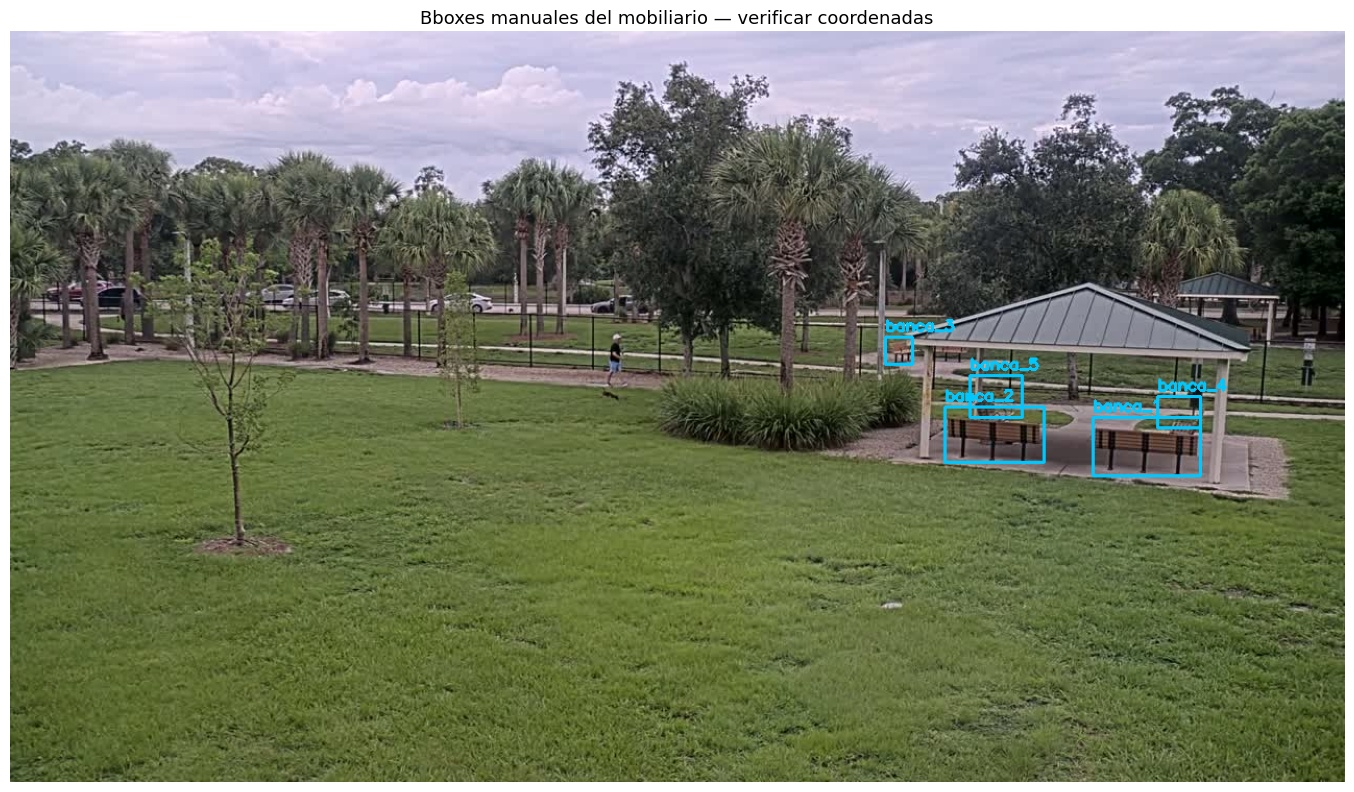

In [55]:
# visualizar para confirmar coordenadas del mobiliario
# (MOBILIARIO_BBOXES está en la celda de config)
def mostrar_bboxes_mobiliario(img_bgr, mobiliario_bboxes):
    img = img_bgr.copy()
    for nombre, (x1, y1, x2, y2) in mobiliario_bboxes.items():
        cv2.rectangle(img, (x1, y1), (x2, y2), COLOR_MOBILIARIO_LIBRE, 2)
        cv2.putText(img, nombre, (x1, y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_MOBILIARIO_LIBRE, 2)
    mostrar_imagen(img, 'Bboxes manuales del mobiliario — verificar coordenadas')

mostrar_bboxes_mobiliario(img_original, MOBILIARIO_BBOXES)

In [56]:
# función inferir uso mobiliario por snapshot
def inferir_uso_snapshot(detecciones, mobiliario_metros=None):
    """
    Cuenta personas y mascotas que están usando cada mueble.
    Retorna {nombre: {ocupado, n_usuarios, n_personas, n_mascotas}}

    #14 RESUELTO con homografía: la ocupación se determina por DISTANCIA REAL en
    metros entre la posición de la persona (pos_m, proyectada desde su foot-point)
    y el centro del mueble. Antes se usaba solape de bboxes en píxeles, que daba
    falsos positivos: una persona parada a 20m alineada en perspectiva con una
    banca contaba como que la usaba.
    """
    if mobiliario_metros is None:
        mobiliario_metros = MOBILIARIO_METROS

    def usa_mueble(det, centro_m):
        """True si la detección está a menos del radio de uso del centro del mueble."""
        if det.get('pos_m') is None:      # ← antes: if 'pos_m' not in det
            return False
        dx = det['pos_m'][0] - centro_m[0]
        dy = det['pos_m'][1] - centro_m[1]
        return (dx*dx + dy*dy) ** 0.5 <= RADIO_USO_MOBILIARIO_M

    resultado = {}
    for nombre, datos in mobiliario_metros.items():
        centro_m   = datos['centro_m']
        n_personas = sum(1 for p in detecciones['personas'] if usa_mueble(p, centro_m))
        n_mascotas = sum(1 for m in detecciones['mascotas'] if usa_mueble(m, centro_m))
        n_usuarios = n_personas + n_mascotas
        resultado[nombre] = {
            'ocupado':    n_usuarios > 0,
            'n_usuarios': n_usuarios,
            'n_personas': n_personas,
            'n_mascotas': n_mascotas,
        }
    return resultado

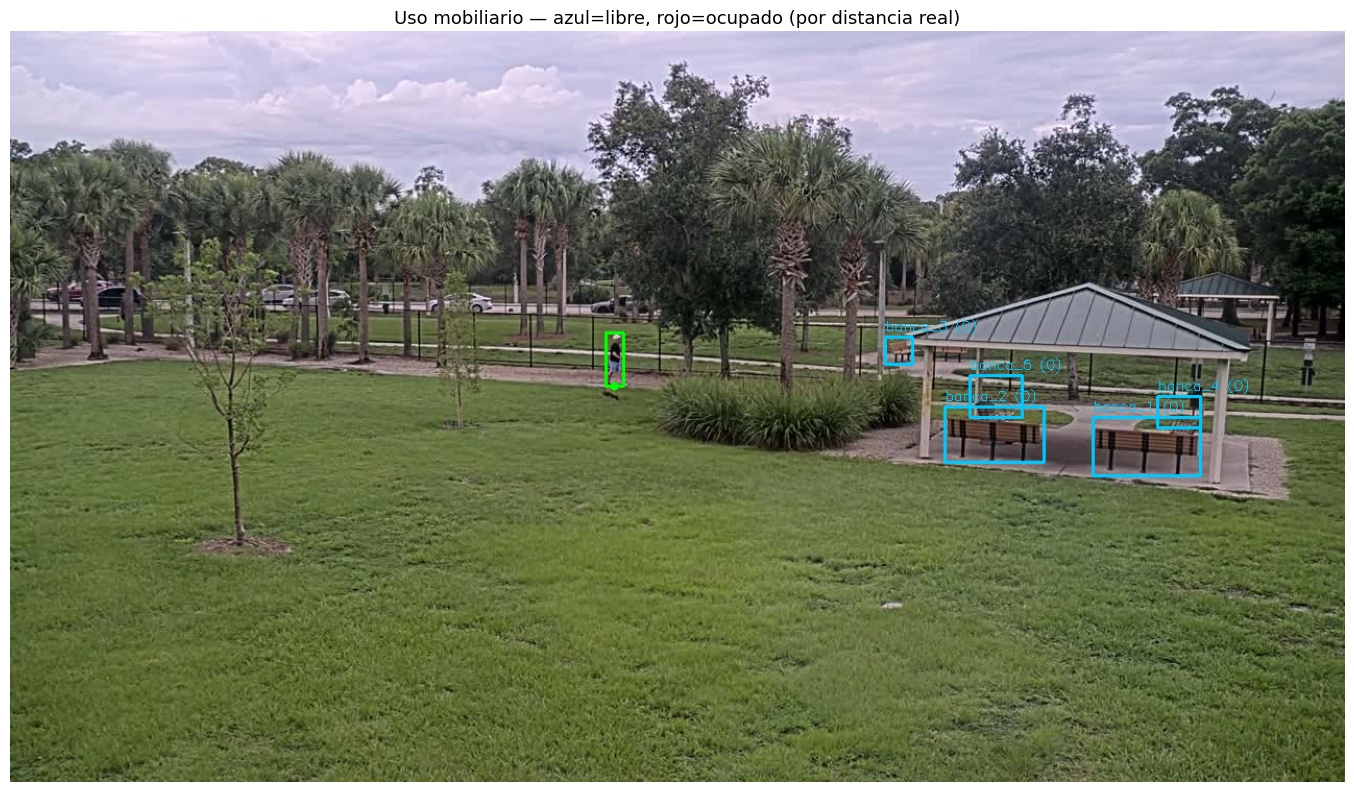


  Mueble          Ocupado    Personas   Mascotas
  ---------------------------------------------
  banca_1         no         0          0
  banca_2         no         0          0
  banca_3         no         0          0
  banca_4         no         0          0
  banca_5         no         0          0

  Distancias reales persona → mueble (radio de uso: 1.5 m):
    P1 en (4.94, 18.62) m → más cercano: banca_5 a 12.59 m


In [57]:
# ejecutar y visualizar uso mobiliario
uso_mobiliario_snapshot = inferir_uso_snapshot(detecciones, MOBILIARIO_METROS)

img_uso = img_original.copy()

# bboxes personas y mascotas
for p in detecciones['personas']:
    x1, y1, x2, y2 = p['bbox']
    cv2.rectangle(img_uso, (x1, y1), (x2, y2), COLOR_PERSONA, 2)
    cv2.circle(img_uso, p['pie'], 4, COLOR_PERSONA, -1)
for m in detecciones['mascotas']:
    x1, y1, x2, y2 = m['bbox']
    cv2.rectangle(img_uso, (x1, y1), (x2, y2), COLOR_MASCOTA, 2)
    cv2.circle(img_uso, m['pie'], 4, COLOR_MASCOTA, -1)

# bboxes mobiliario (solo visualización)
for nombre, (x1, y1, x2, y2) in MOBILIARIO_BBOXES.items():
    estado = uso_mobiliario_snapshot[nombre]
    color  = COLOR_MOBILIARIO_OCUPADO if estado['ocupado'] else COLOR_MOBILIARIO_LIBRE
    cv2.rectangle(img_uso, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_uso, f"{nombre} ({estado['n_usuarios']})", (x1, y1-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

mostrar_imagen(img_uso, 'Uso mobiliario — azul=libre, rojo=ocupado (por distancia real)')

print(f'\n  {"Mueble":<15} {"Ocupado":<10} {"Personas":<10} {"Mascotas"}')
print('  ' + '-'*45)
for nombre, e in uso_mobiliario_snapshot.items():
    print(f'  {nombre:<15} {"sí" if e["ocupado"] else "no":<10} {e["n_personas"]:<10} {e["n_mascotas"]}')

# distancias reales de cada persona a cada mueble (para verificar el criterio)
print(f'\n  Distancias reales persona → mueble (radio de uso: {RADIO_USO_MOBILIARIO_M} m):')
for i, p in enumerate(detecciones['personas']):
    if 'pos_m' not in p:
        continue
    dists = []
    for nombre, d in MOBILIARIO_METROS.items():
        cx, cy = d['centro_m']
        dist = ((p['pos_m'][0]-cx)**2 + (p['pos_m'][1]-cy)**2) ** 0.5
        dists.append((nombre, round(dist, 2)))
    dists.sort(key=lambda t: t[1])
    print(f'    P{i+1} en {p["pos_m"]} m → más cercano: {dists[0][0]} a {dists[0][1]} m')

#### fase 3.5: ordenar data + sensores

In [58]:
# datos sensores
# [CAMBIAR A FUTURO] en producción vienen del HTTP POST del Nodo B junto con la imagen
# sensores: AHT10 (tdb, rh), anemómetro (v), GYML8511 (uv), TEMT6000 (lux)
# [PRUEBA] valores aleatorios; el flag datos_sinteticos marca que NO son reales (#15)
sensor_data = {
    'timestamp': datetime.datetime.now().isoformat(),
    'tdb': round(random.uniform(*SIM_TDB), 1),
    'rh':  round(random.uniform(*SIM_RH), 1),
    'v':   None,
    'uv':  round(random.uniform(*SIM_UV), 1),
    'lux': random.randint(*SIM_LUX),
    'datos_sinteticos': True,   # #15: True = inventados. En producción será False.
}
print('=== SENSOR DATA (sintético) ===')
for k, v in sensor_data.items():
    print(f'  {k}: {v}')

=== SENSOR DATA (sintético) ===
  timestamp: 2026-07-22T09:32:28.290515
  tdb: 22.8
  rh: 36.6
  v: None
  uv: 10.4
  lux: 41745
  datos_sinteticos: True


In [59]:
# construir snapshot record
def construir_snapshot_record(detecciones, mascara_sombra, uso_mobiliario_snapshot,
                               sensor_data, condicion_luz,
                               shade_util_personas, shade_util_mascotas, shade_parque_pct,
                               resultado_vegetacion=None):
    """
    Consolida todos los datos del snapshot en un dict plano.
    Combina outputs de YOLO, homografía, BDRAR, vegetación, mobiliario y sensores.
    """
    hora = datetime.datetime.fromisoformat(sensor_data['timestamp']).hour
    hora_operacional = HORA_APERTURA <= hora < HORA_CIERRE

    # #16: validación real de snapshot
    motivos_invalido = []
    if not (RANGO_VALIDO_TDB[0] <= sensor_data['tdb'] <= RANGO_VALIDO_TDB[1]):
        motivos_invalido.append('tdb fuera de rango')
    if not (RANGO_VALIDO_RH[0] <= sensor_data['rh'] <= RANGO_VALIDO_RH[1]):
        motivos_invalido.append('rh fuera de rango')
    if sensor_data['v'] is not None and not (RANGO_VALIDO_V[0] <= sensor_data['v'] <= RANGO_VALIDO_V[1]):
        motivos_invalido.append('viento fuera de rango')
    snapshot_valido = len(motivos_invalido) == 0

    veg = resultado_vegetacion or {}

    return {
        # sensores
        'timestamp':         sensor_data['timestamp'],
        'tdb':               sensor_data['tdb'],
        'rh':                sensor_data['rh'],
        'v':                 sensor_data['v'],
        'uv':                sensor_data['uv'],
        'lux':               sensor_data['lux'],
        'datos_sinteticos':  sensor_data.get('datos_sinteticos', False),
        'condicion_luz':     condicion_luz,
        'hora_operacional':  hora_operacional,
        'shade_confiable':   condicion_luz == 'diurno',
        'snapshot_valido':   snapshot_valido,
        'motivos_invalido':  motivos_invalido,

        # personas y mascotas
        'n_personas':          len(detecciones['personas']),
        'n_mascotas':          len(detecciones['mascotas']),
        'pies_personas':       [p['pie'] for p in detecciones['personas']],
        'pies_mascotas':       [m['pie'] for m in detecciones['mascotas']],
        # homografía: posiciones en METROS reales (lo que usan las métricas espaciales)
        'pos_m_personas':      [p.get('pos_m') for p in detecciones['personas']],
        'pos_m_mascotas':      [m.get('pos_m') for m in detecciones['mascotas']],
        'shade_util_personas': shade_util_personas,
        'shade_util_mascotas': shade_util_mascotas,
        'shade_parque_pct':    shade_parque_pct,

        # vegetación (Fase 2.5)
        'exg_pasto_prom':      veg.get('exg_prom'),
        'exg_control':         veg.get('exg_control'), 
        'diferencia_exg':      veg.get('diferencia_exg'), 

        # mobiliario
        'uso_mobiliario': uso_mobiliario_snapshot,
    }


snapshot_record = construir_snapshot_record(
    detecciones, mascara_sombra, uso_mobiliario_snapshot,
    sensor_data, condicion_luz,
    shade_util_personas, shade_util_mascotas, shade_parque_pct,
    resultado_veg
)
print('✅ snapshot_record construido')

✅ snapshot_record construido


In [60]:
# verificar snapshot
print('=== RESUMEN SNAPSHOT ===')

print('\n  SENSORES:')
for k in ['timestamp','tdb','rh','v','uv','lux','datos_sinteticos',
          'condicion_luz','hora_operacional','snapshot_valido']:
    print(f'    {k}: {snapshot_record[k]}')
if not snapshot_record['snapshot_valido']:
    print(f'    ⚠️  motivos: {snapshot_record["motivos_invalido"]}')

print('\n  PERSONAS Y MASCOTAS:')
print(f'    n_personas:          {snapshot_record["n_personas"]}')
print(f'    n_mascotas:          {snapshot_record["n_mascotas"]}')

# homografía: posiciones en metros reales
print(f'    pos_m_personas:      {snapshot_record["pos_m_personas"]}')
print(f'    pos_m_mascotas:      {snapshot_record["pos_m_mascotas"]}')

# #12: shade separado; puede ser None si no fue diurno
sp = snapshot_record['shade_util_personas']
sm = snapshot_record['shade_util_mascotas']
pq = snapshot_record['shade_parque_pct']
print(f'    shade_util_personas: {sp if sp is not None else "N/A"}')
print(f'    shade_util_mascotas: {sm if sm is not None else "N/A"}')
print(f'    shade_parque_pct:    {pq if pq is not None else "N/A"}  (sobre máscara de suelo, #8)')
print(f'    shade_confiable:     {snapshot_record["shade_confiable"]}')

print('\n  VEGETACIÓN:')
exg = snapshot_record['exg_pasto_prom']
print(f'    exg_pasto_prom:      {exg if exg is not None else "N/A"}')

print('\n  MOBILIARIO:')
print(f'    {"Mueble":<15} {"Ocupado":<10} {"N usuarios"}')
print('    ' + '-'*37)
for nombre, e in snapshot_record['uso_mobiliario'].items():
    print(f'    {nombre:<15} {"sí" if e["ocupado"] else "no":<10} {e["n_usuarios"]}')

=== RESUMEN SNAPSHOT ===

  SENSORES:
    timestamp: 2026-07-22T09:32:28.290515
    tdb: 22.8
    rh: 36.6
    v: None
    uv: 10.4
    lux: 41745
    datos_sinteticos: True
    condicion_luz: diurno
    hora_operacional: True
    snapshot_valido: True

  PERSONAS Y MASCOTAS:
    n_personas:          1
    n_mascotas:          0
    pos_m_personas:      [(4.94, 18.62)]
    pos_m_mascotas:      []
    shade_util_personas: 0.0
    shade_util_mascotas: 0.0
    shade_parque_pct:    0.005  (sobre máscara de suelo, #8)
    shade_confiable:     True

  VEGETACIÓN:
    exg_pasto_prom:      0.2405

  MOBILIARIO:
    Mueble          Ocupado    N usuarios
    -------------------------------------
    banca_1         no         0
    banca_2         no         0
    banca_3         no         0
    banca_4         no         0
    banca_5         no         0


#### FASE 4: PYTHERMALCOMFORT

In [61]:
# funciones UTCI — modelo ERA5 (#18), reemplaza la fórmula inventada

def elevacion_solar(timestamp, lat=LAT_MODELO, lon=LON_MODELO):
    """Elevación del sol en grados. timestamp en UTC (naive)."""
    n = timestamp.timetuple().tm_yday
    decl = np.radians(23.45 * np.sin(np.radians(360 / 365 * (284 + n))))
    hora_solar = timestamp.hour + timestamp.minute / 60 + lon / 15
    ang_h = np.radians(15 * (hora_solar - 12))
    lat_r = np.radians(lat)
    return np.degrees(np.arcsin(np.clip(
        np.sin(lat_r) * np.sin(decl) + np.cos(lat_r) * np.cos(decl) * np.cos(ang_h),
        -1, 1)))


def radiacion_cielo_despejado(elev_grados):
    """Radiación global horizontal con cielo despejado, W/m² (Haurwitz, 1945)."""
    s = np.sin(np.radians(np.clip(elev_grados, 0, 90)))
    if s < 1e-3:
        return 0.0
    return float(1098 * s * np.exp(-0.059 / s))


def obtener_viento(timestamp, viento_sensor):
    """(viento_m_s, viento_es_real).

    Usa el sensor si llega un valor real (anemómetro instalado). Si no (caso
    actual, sin anemómetro comprado — documento 01/04), usa el promedio
    climatológico de ese mes y esa hora local. No hay caso de "sin dato": la
    tabla cubre las 288 combinaciones mes×hora posibles.
    """
    if viento_sensor is not None:
        return float(viento_sensor), True
    hora_local = (timestamp.hour + UTC_OFFSET_MODELO) % 24
    mes = timestamp.month
    v = VIENTO_CLIMA['climatologia'].get((mes, hora_local))
    if v is None:
        v = float(np.mean(list(VIENTO_CLIMA['climatologia'].values())))
    return float(v), False


def calcular_tr(timestamp, tdb, rh, viento_sensor):
    """
    Predice tr (temperatura radiante media) con el modelo entrenado con ERA5.
    Reemplaza la fórmula inventada `tdb + uv * 1.8 * (1 - sombra)` (#18).

    Devuelve (tr, viento_usado, viento_es_real) — el viento se devuelve junto
    con tr porque calcular_y_clasificar_utci() también lo necesita para la
    fórmula final de UTCI, y el flag para el disclaimer.
    """
    viento, viento_es_real = obtener_viento(timestamp, viento_sensor)

    elev = elevacion_solar(timestamp)
    rad = radiacion_cielo_despejado(elev)
    hora_local = (timestamp.hour + UTC_OFFSET_MODELO) % 24
    dia = timestamp.timetuple().tm_yday

    valores = {
        't2m_c': tdb,
        'rh': rh,
        'viento': viento,
        'elev_solar': elev,
        'rad_cielo_despejado': rad,
        'hora_sin': np.sin(2 * np.pi * hora_local / 24),
        'hora_cos': np.cos(2 * np.pi * hora_local / 24),
        'dia_sin': np.sin(2 * np.pi * dia / 365),
        'dia_cos': np.cos(2 * np.pi * dia / 365),
    }

    # Orden exacto de FEATURES_MODELO_MRT — si no calza con el entrenamiento,
    # el modelo predice basura sin avisar.
    X = np.array([[valores[f] for f in FEATURES_MODELO_MRT]])
    X_scaled = SCALER_MRT.transform(X)
    tr = float(MODELO_MRT.predict(X_scaled)[0])

    return round(tr, 2), viento, viento_es_real


def clasificar_utci(utci_valor):
    """Clasifica UTCI en la escala oficial completa (#19). Sin cambios."""
    for corte, etiqueta in UTCI_CORTES:
        if utci_valor > corte:
            return etiqueta
    return UTCI_CORTES[-1][1]


def calcular_y_clasificar_utci(sensor_data, shade_parque_pct):
    """Calcula UTCI y lo clasifica.

    Firma SIN CAMBIOS respecto de la versión anterior — mismo llamado en la
    celda siguiente y en procesar_snapshot(), cambia lo de adentro, no cómo
    se invoca. shade_parque_pct queda en la firma por compatibilidad: el
    modelo hoy no ajusta por sombra local (eso es el mapa de islas de calor,
    documento 05 prioridad media, trabajo futuro) — UTCI sigue siendo global
    por snapshot, como ya estaba documentado.
    """
    tdb = sensor_data['tdb']
    ts = datetime.datetime.fromisoformat(sensor_data['timestamp'])
    tr, viento_usado, viento_es_real = calcular_tr(
        ts, tdb, sensor_data['rh'], sensor_data.get('v'))

    # #20: viento fuera del rango válido de pythermalcomfort → UTCI puede dar NaN
    v = float(np.clip(viento_usado, *UTCI_RANGO_V))

    utci_valor = round(float(utci(tdb=tdb, tr=tr, v=v, rh=sensor_data['rh']).utci), 2)
    return {
        'utci_valor':           utci_valor,
        'utci_categoria':       clasificar_utci(utci_valor),
        'tr_estimada':          tr,
        'viento_usado':         round(viento_usado, 2),
        'viento_es_real':       viento_es_real,
        'utci_viento_estimado': not viento_es_real,
    }

=== UTCI ===
  tdb=22.8°C  tr=6.77°C  v=1.21m/s (climatológico, sin anemómetro)  rh=36.6%
  UTCI: 16.5°C — sin estrés térmico
  ⚠️  UTCI calculado con viento estimado, no medido en el sitio (documento 04)


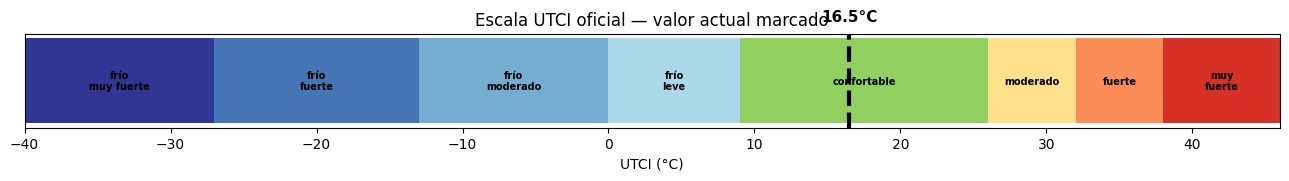

In [62]:
# ejecutar UTCI y agregar al snapshot
resultado_utci = calcular_y_clasificar_utci(
    sensor_data, snapshot_record['shade_parque_pct']
)
snapshot_record['utci_valor']           = resultado_utci['utci_valor']
snapshot_record['utci_categoria']       = resultado_utci['utci_categoria']
snapshot_record['tr_estimada']          = resultado_utci['tr_estimada']
snapshot_record['viento_usado']         = resultado_utci['viento_usado']
snapshot_record['viento_es_real']       = resultado_utci['viento_es_real']
snapshot_record['utci_viento_estimado'] = resultado_utci['utci_viento_estimado']

print('=== UTCI ===')
fuente_v = 'real (anemómetro)' if resultado_utci['viento_es_real'] else 'climatológico, sin anemómetro'
print(f'  tdb={sensor_data["tdb"]}°C  tr={resultado_utci["tr_estimada"]}°C  '
      f'v={resultado_utci["viento_usado"]}m/s ({fuente_v})  rh={sensor_data["rh"]}%')
print(f'  UTCI: {resultado_utci["utci_valor"]}°C — {resultado_utci["utci_categoria"]}')
if resultado_utci['utci_viento_estimado']:
    print('  ⚠️  UTCI calculado con viento estimado, no medido en el sitio (documento 04)')

# barra escala UTCI (escala oficial completa, #19) — SIN CAMBIOS, queda igual
# segmentos: (inicio, fin, color, etiqueta corta)
segmentos = [
    (-40,  -27, '#313695', 'frío\nmuy fuerte'),
    (-27,  -13, '#4575b4', 'frío\nfuerte'),
    (-13,    0, '#74add1', 'frío\nmoderado'),
    (  0,    9, '#abd9e9', 'frío\nleve'),
    (  9,   26, '#91cf60', 'confortable'),
    ( 26,   32, '#fee08b', 'moderado'),
    ( 32,   38, '#fc8d59', 'fuerte'),
    ( 38,   46, '#d73027', 'muy\nfuerte'),
]

plt.close('all')
fig, ax = plt.subplots(figsize=(13, 2))
for ini, fin, color, etiq in segmentos:
    ax.barh(0, fin-ini, left=ini, color=color, height=0.5)
    ax.text((ini+fin)/2, 0, etiq, ha='center', va='center',
            fontsize=7, fontweight='bold', color='black')
uv_val = resultado_utci['utci_valor']
ax.axvline(x=uv_val, color='black', linewidth=3, linestyle='--')
ax.text(uv_val, 0.35, f'{uv_val}°C', ha='center', fontsize=11, fontweight='bold')
ax.set_xlim(-40, 46)
ax.set_xlabel('UTCI (°C)')
ax.set_yticks([])
ax.set_title('Escala UTCI oficial — valor actual marcado', fontsize=12)
plt.tight_layout()
plt.show()

#### FASE 5: amononar datos

In [63]:
# función calcular aglomeración
def calcular_aglomeracion(n_personas, area_m2=None):
    """
    Calcula densidad real de personas y detecta aglomeración.

    #21 RESUELTO con homografía: la densidad se calcula sobre el ÁREA REALMENTE
    OBSERVADA por la cámara (proyectada al plano), no sobre el área total del
    parque. Antes era n_personas/3000, que era el conteo por una constante.

    """
    if area_m2 is None:
        area_m2 = AREA_OBSERVADA_M2

    densidad = round(n_personas / area_m2, 4) if area_m2 > 0 else None
    return {
        'densidad':            densidad,
        'aglomeracion':        densidad > UMBRAL_AGLOMERACION if densidad is not None else False,
        'densidad_confiable':  True,
        'area_observada_m2':   area_m2,
    }

=== RESUMEN FINAL SNAPSHOT ===
  timestamp:           2026-07-22T09:32:28.290515
  snapshot_valido:     True
  datos_sinteticos:    True
  condicion_luz:       diurno
  n_personas:          1
  n_mascotas:          0
  area observada:      14814.1 m² (proyectada por homografía)
  densidad:            0.0001 p/m²  [confiable]
  aglomeracion:        False  (umbral 0.13 p/m², estándar caniles)
  shade personas:      0.0
  shade mascotas:      0.0
  ExG pasto:           0.2405
  UTCI:                16.5°C — sin estrés térmico

  MOBILIARIO:
    banca_1         libre  (0 usuarios)
    banca_2         libre  (0 usuarios)
    banca_3         libre  (0 usuarios)
    banca_4         libre  (0 usuarios)
    banca_5         libre  (0 usuarios)


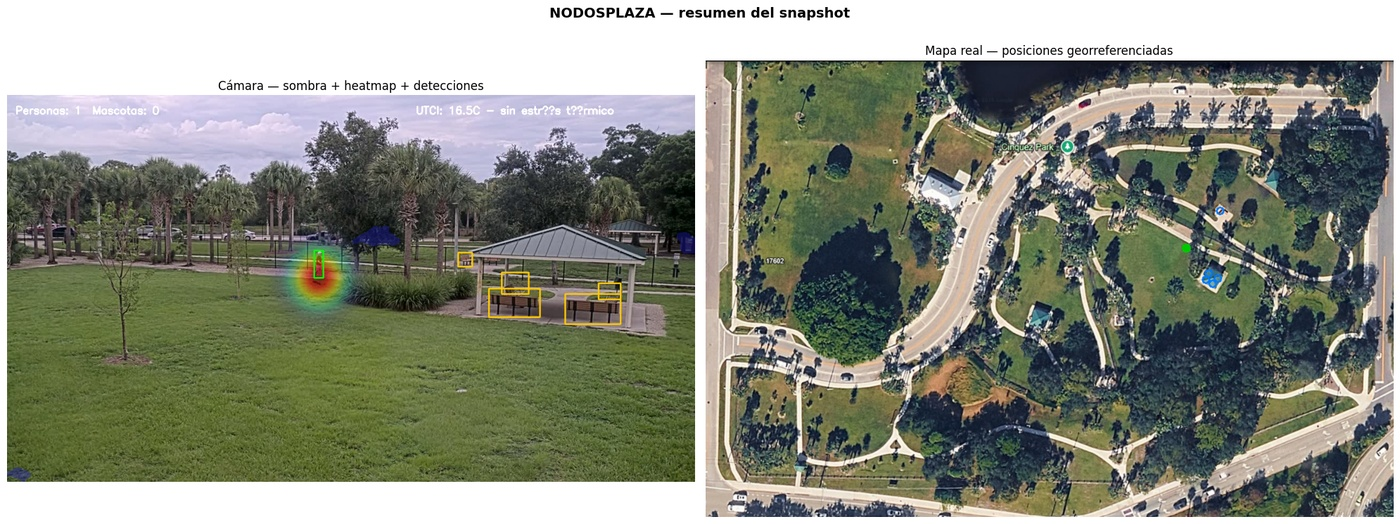

In [64]:
# ejecutar aglomeración y resumen final snapshot
resultado_aglomeracion = calcular_aglomeracion(snapshot_record['n_personas'])
snapshot_record['densidad']             = resultado_aglomeracion['densidad']
snapshot_record['aglomeracion']         = resultado_aglomeracion['aglomeracion']
snapshot_record['densidad_confiable']   = resultado_aglomeracion['densidad_confiable']
snapshot_record['area_observada_m2']    = resultado_aglomeracion['area_observada_m2']  # #21

print('=== RESUMEN FINAL SNAPSHOT ===')
print(f'  timestamp:           {snapshot_record["timestamp"]}')
print(f'  snapshot_valido:     {snapshot_record["snapshot_valido"]}')
print(f'  datos_sinteticos:    {snapshot_record["datos_sinteticos"]}')
print(f'  condicion_luz:       {snapshot_record["condicion_luz"]}')
print(f'  n_personas:          {snapshot_record["n_personas"]}')
print(f'  n_mascotas:          {snapshot_record["n_mascotas"]}')
# #21 RESUELTO: densidad real sobre área observada
print(f'  area observada:      {snapshot_record["area_observada_m2"]} m² (proyectada por homografía)')
print(f'  densidad:            {snapshot_record["densidad"]} p/m²'
      f'  [{"confiable" if snapshot_record["densidad_confiable"] else "NO confiable"}]')
print(f'  aglomeracion:        {snapshot_record["aglomeracion"]}'
      f'  (umbral {UMBRAL_AGLOMERACION} p/m², estándar caniles)')
# #12: shade separado
sp = snapshot_record['shade_util_personas']
sm = snapshot_record['shade_util_mascotas']
print(f'  shade personas:      {sp if sp is not None else "N/A"}')
print(f'  shade mascotas:      {sm if sm is not None else "N/A"}')
exg = snapshot_record['exg_pasto_prom']
print(f'  ExG pasto:           {exg if exg is not None else "N/A"}')
print(f'  UTCI:                {snapshot_record["utci_valor"]}°C — {snapshot_record["utci_categoria"]}')
print(f'\n  MOBILIARIO:')
for nombre, e in snapshot_record['uso_mobiliario'].items():
    print(f'    {nombre:<15} {"ocupado" if e["ocupado"] else "libre"}  ({e["n_usuarios"]} usuarios)')

# ── visualización final: frame + mapa satelital ──────────────────────────────
img_rgb    = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).astype(np.float32)
mascara_3d = mascara_sombra[:, :, np.newaxis]
img_base   = img_rgb * (1 - mascara_3d * 0.4) + \
             np.array([30, 30, 180], dtype=np.float32) * (mascara_3d * 0.4)

calor_mask = canvas_heatmap[:, :, np.newaxis]
img_final  = img_base * (1 - calor_mask * 0.6) + \
             plt.cm.jet(canvas_heatmap)[:,:,:3] * 255 * (calor_mask * 0.6)
img_final  = np.clip(img_final, 0, 255).astype(np.uint8)

for p in detecciones['personas']:
    x1,y1,x2,y2 = p['bbox']
    cv2.rectangle(img_final, (x1,y1), (x2,y2), COLOR_PERSONA, 2)
for m in detecciones['mascotas']:
    x1,y1,x2,y2 = m['bbox']
    cv2.rectangle(img_final, (x1,y1), (x2,y2), COLOR_MASCOTA, 2)
for nombre, (x1,y1,x2,y2) in MOBILIARIO_BBOXES.items():
    color = COLOR_MOBILIARIO_OCUPADO if snapshot_record['uso_mobiliario'][nombre]['ocupado'] \
            else COLOR_MOBILIARIO_LIBRE
    cv2.rectangle(img_final, (x1,y1), (x2,y2), color, 2)

cv2.putText(img_final, f"UTCI: {snapshot_record['utci_valor']}C - {snapshot_record['utci_categoria']}",
            (ANCHO-520, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)
cv2.putText(img_final, f"Personas: {snapshot_record['n_personas']}  Mascotas: {snapshot_record['n_mascotas']}",
            (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)

# mapa satelital con las detecciones proyectadas (#7: plano cenital, sin distorsión)
sat_final = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()
for i, p in enumerate(detecciones['personas']):
    if p.get('pos_m'):
        sx, sy = metros_a_satelital(p['pos_m'], H_METROS_SAT)
        cv2.circle(sat_final, (sx, sy), 8, (0, 200, 0), -1)
for m in detecciones['mascotas']:
    if m.get('pos_m'):
        sx, sy = metros_a_satelital(m['pos_m'], H_METROS_SAT)
        cv2.circle(sat_final, (sx, sy), 8, (255, 140, 0), -1)
for nombre, d in MOBILIARIO_METROS.items():
    sx, sy = metros_a_satelital(d['centro_m'], H_METROS_SAT)
    col = (255,0,0) if snapshot_record['uso_mobiliario'][nombre]['ocupado'] else (0,120,255)
    cv2.circle(sat_final, (sx, sy), 6, col, 2)

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.imshow(img_final)
ax1.set_title('Cámara — sombra + heatmap + detecciones', fontsize=12)
ax1.axis('off')
ax2.imshow(sat_final)
ax2.set_title('Mapa real — posiciones georreferenciadas', fontsize=12)
ax2.axis('off')
plt.suptitle('NODOSPLAZA — resumen del snapshot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### fase 5.5: guardar data en bd

In [65]:
# setup BD — CSV local
# (RUTA_CSV y HEADERS están en la celda de config)

def init_csv(ruta, headers):
    """Crea el CSV con headers si no existe. Si ya existe solo hace append."""
    if not os.path.exists(ruta):
        with open(ruta, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=headers, quoting=csv.QUOTE_ALL).writeheader()
        print(f'✅ CSV creado: {ruta}')
    else:
        print(f'✅ CSV ya existe: {ruta}')

def cargar_timestamps_existentes(ruta):
    """#23: carga UNA vez los timestamps ya presentes en el CSV a un set.
    Antes se releía el CSV entero por cada snapshot (O(n²) en un batch);
    ahora se lee una sola vez y la deduplicación queda en O(1) por snapshot.
    Devuelve un set de strings (vacío si el CSV no existe todavía)."""
    if not os.path.exists(ruta):
        return set()
    try:
        df = pd.read_csv(ruta, usecols=['timestamp'])
        return set(df['timestamp'].astype(str))
    except Exception:
        return set()

def guardar_snapshot(snapshot_record, ruta, headers, ts_vistos):
    """Agrega una fila al CSV. Serializa listas/dicts como JSON. Evita
    duplicados (#23) consultando ts_vistos (set en memoria, O(1)) en vez de
    releer el CSV. Muta ts_vistos al guardar con éxito: la función que guarda
    es la única fuente de verdad de qué ya se guardó."""
    ts = str(snapshot_record['timestamp'])
    if ts in ts_vistos:
        print(f'⚠️  Snapshot duplicado (ya existe {ts}) — no se guarda')
        return False
    fila = {
        campo: json.dumps(snapshot_record.get(campo), ensure_ascii=False)
               if isinstance(snapshot_record.get(campo), (list, dict))
               else snapshot_record.get(campo)
        for campo in headers
    }
    # #24: QUOTE_ALL encierra cada campo en comillas → protege las comas del JSON
    with open(ruta, 'a', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=headers, quoting=csv.QUOTE_ALL).writerow(fila)
    ts_vistos.add(ts)   # mantener el set sincronizado con el disco
    print(f'✅ Snapshot guardado — {ts}')
    return True

print('✅ Funciones CSV definidas')

✅ Funciones CSV definidas


In [66]:
# ── Fase 5.5: guardado — demostración (NO persiste) ──────────────────────────
# El snapshot individual es demostrativo: muestra qué campos produce el pipeline
# para UNA imagen. NO se guarda en el CSV para no mezclar una demo con el dataset
# del batch (además su timestamp sería datetime.now(), no el del frame).
# El guardado real ocurre en el batch, con timestamps reales de cada frame.

print('=== SNAPSHOT RECORD (demostración, no se guarda) ===')
print(f'  campos: {len(snapshot_record)}')
for k, v in snapshot_record.items():
    v_str = str(v)
    if len(v_str) > 70:
        v_str = v_str[:67] + '...'
    print(f'    {k:<22} {v_str}')

# verificar que los campos del record coinciden con los HEADERS del CSV
faltantes = [h for h in HEADERS if h not in snapshot_record]
sobrantes = [k for k in snapshot_record if k not in HEADERS]
if faltantes:
    print(f'\n⚠️  en HEADERS pero no en el record: {faltantes}')
if sobrantes:
    print(f'⚠️  en el record pero no en HEADERS: {sobrantes}')
if not faltantes and not sobrantes:
    print('\n✅ snapshot_record y HEADERS coinciden')

=== SNAPSHOT RECORD (demostración, no se guarda) ===
  campos: 35
    timestamp              2026-07-22T09:32:28.290515
    tdb                    22.8
    rh                     36.6
    v                      None
    uv                     10.4
    lux                    41745
    datos_sinteticos       True
    condicion_luz          diurno
    hora_operacional       True
    shade_confiable        True
    snapshot_valido        True
    motivos_invalido       []
    n_personas             1
    n_mascotas             0
    pies_personas          [(579, 340)]
    pies_mascotas          []
    pos_m_personas         [(4.94, 18.62)]
    pos_m_mascotas         []
    shade_util_personas    0.0
    shade_util_mascotas    0.0
    shade_parque_pct       0.005
    exg_pasto_prom         0.2405
    exg_control            0.2833
    diferencia_exg         -0.0428
    uso_mobiliario         {'banca_1': {'ocupado': False, 'n_usuarios': 0, 'n_personas': 0, 'n...
    utci_valor             16.

#### FASE 6: procesar data batch

In [67]:
# ── FUNCIÓN CONSOLIDADA DE PROCESAMIENTO POR IMAGEN ──────────────────────────
# #C: una sola fuente de verdad. Encapsula fases 1-5 reusando las funciones ya
# definidas. La usan tanto el batch como (a futuro) el FastAPI de producción.

def procesar_snapshot(img_bgr, sensor_data, lux_es_real=False):
    """
    Procesa UNA imagen + sensores y devuelve el snapshot_record completo.
    Incluye homografía (pos_m), vegetación (ExG) y densidad real.
    """
    if img_bgr.shape[:2] != (ALTO, ANCHO):
        img_bgr = cv2.resize(img_bgr, (ANCHO, ALTO))

    # Fase 1: YOLO
    det = correr_yolo(img_bgr, modelo_yolo)

    # Fase 1.5: proyectar detecciones a metros reales (homografía)
    det = proyectar_detecciones(det, H_HOMOGRAFIA)

    # Fase 2: condición de luz (fuente única) + sombra
    condicion_luz = determinar_condicion_luz(
        img_bgr, lux=sensor_data.get('lux'), lux_es_real=lux_es_real)

    shade_util_personas = None
    shade_util_mascotas = None
    shade_parque_pct    = None

    if condicion_luz != 'diurno' or modelo_bdrar is None:
        masc = np.zeros((ALTO, ANCHO), dtype=np.uint8)
    else:
        masc = detectar_sombra(img_bgr, modelo_bdrar)
        for d in det['personas'] + det['mascotas']:
            d['en_sombra'], d['pct_sombra'] = region_en_sombra(d['bbox'], masc)
        def _su(lista):
            return round(sum(1 for d in lista if d['en_sombra']) / len(lista), 3) if lista else 0.0
        shade_util_personas = _su(det['personas'])
        shade_util_mascotas = _su(det['mascotas'])
        # #8: sobre máscara de SUELO (bajo el horizonte), no toda la imagen
        shade_parque_pct    = round(float(np.mean(masc[MASCARA_SUELO == 1])), 3)

    # Fase 2.5: vegetación (ExG sobre zona de pasto)
    res_veg = calcular_exg(img_bgr, MASCARA_PASTO)
    res_veg.update(comparar_vegetacion_uso_control(res_veg['exg_prom'], img_bgr, MASCARA_CONTROL))

    # Fase 3: uso mobiliario — #14: por distancia real en metros
    uso_mob = inferir_uso_snapshot(det, MOBILIARIO_METROS)

    # Fase 3.5: construir record
    snap = construir_snapshot_record(
        det, masc, uso_mob, sensor_data, condicion_luz,
        shade_util_personas, shade_util_mascotas, shade_parque_pct,
        res_veg)

    # Fase 4: UTCI
    res_utci = calcular_y_clasificar_utci(sensor_data, shade_parque_pct)
    snap['utci_valor']           = res_utci['utci_valor']
    snap['utci_categoria']       = res_utci['utci_categoria']
    snap['tr_estimada']          = res_utci['tr_estimada']
    snap['viento_usado']         = res_utci['viento_usado']
    snap['viento_es_real']       = res_utci['viento_es_real']
    snap['utci_viento_estimado'] = res_utci['utci_viento_estimado']

    # Fase 5: aglomeración — #21: densidad real sobre área observada
    res_agl = calcular_aglomeracion(snap['n_personas'])
    snap['densidad']            = res_agl['densidad']
    snap['aglomeracion']        = res_agl['aglomeracion']
    snap['densidad_confiable']  = res_agl['densidad_confiable']
    snap['area_observada_m2']   = res_agl['area_observada_m2']

    return snap

print('✅ procesar_snapshot() definida')

✅ procesar_snapshot() definida


In [68]:
# verificación: procesar_snapshot debe dar lo mismo que el cálculo manual de arriba
snap_test = procesar_snapshot(img_original, sensor_data, lux_es_real=False)
print('n_personas:', snap_test['n_personas'], '| UTCI:', snap_test['utci_valor'],
      '| categoria:', snap_test['utci_categoria'])

n_personas: 1 | UTCI: 16.5 | categoria: sin estrés térmico


In [ ]:
# ── generar dataset de prueba (submuestreo por timestamp real) ───
CARPETA_BATCH        = '../frames_cinquez_20260530/'  # [AJUSTABLE]
INTERVALO_MUESTREO_SEG = 5    # [AJUSTABLE] 
DURACION_MAX_MIN       = 360    # [AJUSTABLE] 1 hora → ~360 frames, cubre tendencias visibles / 10min-pa probar q funque/ 360 min son 6 horas, mas o menos la duracion de los frames de prueba

def ts_desde_nombre(ruta):
    """Extrae datetime del nombre 20260530_131329.jpg. None si no parsea."""
    nombre = os.path.basename(ruta).replace('.jpg', '')
    try:
        return datetime.datetime.strptime(nombre, '%Y%m%d_%H%M%S')
    except ValueError:
        return None

def submuestrear_frames(carpeta, intervalo_seg, duracion_max_min):
    """Toma frames espaciados >= intervalo_seg segun su timestamp real, hasta
    cubrir duracion_max_min. Devuelve lista de (ruta, timestamp)."""
    todos = sorted(glob.glob(f'{carpeta}*.jpg'))
    seleccion = []
    t_inicio = None
    t_ultimo = None
    for ruta in todos:
        ts = ts_desde_nombre(ruta)
        if ts is None:
            continue
        if t_inicio is None:
            t_inicio = ts
        # cortar si superamos la duración máxima
        if (ts - t_inicio).total_seconds() / 60 > duracion_max_min:
            break
        # tomar si es el primero o si pasó el intervalo desde el último tomado
        if t_ultimo is None or (ts - t_ultimo).total_seconds() >= intervalo_seg:
            seleccion.append((ruta, ts))
            t_ultimo = ts
    return seleccion

frames_sel = submuestrear_frames(CARPETA_BATCH, INTERVALO_MUESTREO_SEG, DURACION_MAX_MIN)
print(f'Frames seleccionados: {len(frames_sel)} '
      f'(cada {INTERVALO_MUESTREO_SEG}s, {DURACION_MAX_MIN}min)')
if frames_sel:
    print(f'  desde {frames_sel[0][1]} hasta {frames_sel[-1][1]}')

init_csv(RUTA_CSV, HEADERS)
ts_vistos = cargar_timestamps_existentes(RUTA_CSV)

def simular_sensores(timestamp_iso):
    """[PRUEBA] sensores sintéticos marcados con datos_sinteticos=True (#15)."""
    return {
        'timestamp': timestamp_iso,
        'tdb': round(random.uniform(*SIM_TDB), 1),
        'rh':  round(random.uniform(*SIM_RH), 1),
        'v':   None,
        'uv':  round(random.uniform(*SIM_UV), 1),
        'lux': random.randint(*SIM_LUX),
        'datos_sinteticos': True,
    }

n_guardados = 0
for i, (ruta_frame, ts) in enumerate(frames_sel):
    img  = cargar_imagen_local(ruta_frame)
    sd   = simular_sensores(ts.isoformat())
    snap = procesar_snapshot(img, sd, lux_es_real=False)
    if guardar_snapshot(snap, RUTA_CSV, HEADERS, ts_vistos):
        n_guardados += 1
    if (i+1) % 50 == 0:
        print(f'  [{i+1}/{len(frames_sel)}] procesados')

print(f'\n✅ {len(frames_sel)} frames procesados, {n_guardados} guardados')

Frames seleccionados: 3962 (cada 5s, 360min)
  desde 2026-05-30 13:13:29 hasta 2026-05-30 19:13:25
✅ CSV creado: snapshots.csv
✅ Snapshot guardado — 2026-05-30T13:13:29
✅ Snapshot guardado — 2026-05-30T13:13:34
✅ Snapshot guardado — 2026-05-30T13:13:39
✅ Snapshot guardado — 2026-05-30T13:13:44
✅ Snapshot guardado — 2026-05-30T13:13:49
✅ Snapshot guardado — 2026-05-30T13:13:54
✅ Snapshot guardado — 2026-05-30T13:13:59
✅ Snapshot guardado — 2026-05-30T13:14:05
✅ Snapshot guardado — 2026-05-30T13:14:10
✅ Snapshot guardado — 2026-05-30T13:14:15
✅ Snapshot guardado — 2026-05-30T13:14:20
✅ Snapshot guardado — 2026-05-30T13:14:25
✅ Snapshot guardado — 2026-05-30T13:14:30
✅ Snapshot guardado — 2026-05-30T13:14:35
✅ Snapshot guardado — 2026-05-30T13:14:40
✅ Snapshot guardado — 2026-05-30T13:14:46
✅ Snapshot guardado — 2026-05-30T13:14:51

... [4,006 líneas omitidas al aligerar el notebook para poder subirlo a GitHub] ...

✅ Snapshot guardado — 2026-05-30T19:12:05
✅ Snapshot guardado — 2026-05-3

In [70]:
# cargar histórico desde CSV
# [PROD] reemplazar por query a PostgreSQL
def cargar_historico(ruta, n_ultimos=None, horas=None, solo_validos=True, solo_reales=False):
    """
    Carga snapshots desde CSV, deserializa JSON, ordena por tiempo.
    #16: solo_validos filtra snapshot_valido == True.
    #15: solo_reales filtra datos_sinteticos == False (para correlaciones, etc.).
    [PROD] en producción: reemplazar por query a PostgreSQL.
    """
    df = pd.read_csv(ruta)

    # deserializar columnas JSON
    for col in ['pies_personas', 'pies_mascotas',
                'pos_m_personas', 'pos_m_mascotas',    # ← agregar (homografía)
                'uso_mobiliario', 'motivos_invalido']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.loads(x) if pd.notna(x) else [])

    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df = df.sort_values('timestamp').reset_index(drop=True)

    # #16: filtrar inválidos
    if solo_validos and 'snapshot_valido' in df.columns:
        antes = len(df)
        df = df[df['snapshot_valido'] == True].reset_index(drop=True)
        if antes - len(df) > 0:
            print(f'   {antes - len(df)} snapshots inválidos excluidos (#16)')

    # #15: filtrar sintéticos si se pide
    if solo_reales and 'datos_sinteticos' in df.columns:
        antes = len(df)
        df = df[df['datos_sinteticos'] == False].reset_index(drop=True)
        if antes - len(df) > 0:
            print(f'   {antes - len(df)} snapshots sintéticos excluidos (#15)')

    if horas is not None:
        corte = df['timestamp'].max() - pd.Timedelta(hours=horas)
        df    = df[df['timestamp'] >= corte].reset_index(drop=True)
    if n_ultimos is not None:
        df = df.tail(n_ultimos).reset_index(drop=True)

    print(f'✅ {len(df)} snapshots cargados')
    if len(df) > 0:
        print(f'   Rango: {df["timestamp"].min()} → {df["timestamp"].max()}')
    return df

df_historico = cargar_historico(RUTA_CSV)

✅ 3962 snapshots cargados
   Rango: 2026-05-30 13:13:29 → 2026-05-30 19:13:25


In [71]:
# ── ocupación sostenida ──────────────────────────────────────────────────────

def intervalo_mediano_seg(df):
    """Intervalo real entre snapshots (mediana de diferencias de timestamp).
    Robusto: funciona con cualquier framerate sin asumirlo. Devuelve segundos."""
    if len(df) < 2:
        return None
    difs = df['timestamp'].sort_values().diff().dt.total_seconds().dropna()
    return float(difs.median())

def calcular_ocupacion_sostenida(df):
    """
    Cuenta la máxima racha de snapshots CONSECUTIVOS con presencia de personas.
    El intervalo se calcula desde los timestamps reales, no se asume.

    #27 ADVERTENCIA: esto NO es dwell time individual. Una racha de 12 snapshots
    "con personas" puede ser 12 personas distintas entrando y saliendo, no una
    persona quedándose. Mide presencia continua del espacio, no permanencia de
    individuos. El nombre evita prometer tracking (imposible a este intervalo, #25).
    """
    intervalo_seg = intervalo_mediano_seg(df)

    con_personas = df['n_personas'] > 0
    max_consec = consec = 0
    for tiene in con_personas:
        consec = consec + 1 if tiene else 0
        max_consec = max(max_consec, consec)

    presencia_min = round(max_consec * intervalo_seg / 60, 1) if intervalo_seg else None

    resultado = {
        'n_snapshots_con_personas':  int(con_personas.sum()),
        'n_snapshots_total':         len(df),
        'max_consecutivos':          max_consec,
        'intervalo_real_seg':        round(intervalo_seg, 1) if intervalo_seg else None,
        'presencia_continua_min':    presencia_min,
    }
    print(f'Snapshots con personas:  {resultado["n_snapshots_con_personas"]}/{resultado["n_snapshots_total"]}')
    print(f'Intervalo real:          {resultado["intervalo_real_seg"]} seg entre snapshots')
    print(f'Máx. racha consecutiva:  {resultado["max_consecutivos"]} snapshots')
    print(f'Presencia continua:      {resultado["presencia_continua_min"]} min '
          f'(NO es permanencia individual, ver #27)')
    return resultado

ocupacion = calcular_ocupacion_sostenida(df_historico)

Snapshots con personas:  1445/3962
Intervalo real:          5.0 seg entre snapshots
Máx. racha consecutiva:  82 snapshots
Presencia continua:      6.8 min (NO es permanencia individual, ver #27)


In [72]:
# activity classification (con guard de framerate #25)

def calcular_activity_classification(df):
    """
    Clasifica personas/mascotas en reposo vs circulando comparando posiciones
    (foot-point) entre snapshots consecutivos.

    #25 GUARD DE FRAMERATE: solo se calcula si el intervalo entre snapshots es
    suficientemente corto (<= UMBRAL_INTERVALO_ACTIVITY_SEG). A intervalos largos
    no se puede emparejar individuos entre frames (una persona cruza el parque
    entre snapshot y snapshot), así que la métrica no aplica y se marca dormida.
    """
    intervalo_seg = intervalo_mediano_seg(df)

    # #25: verificar que el framerate permite tracking
    if intervalo_seg is None or intervalo_seg > UMBRAL_INTERVALO_ACTIVITY_SEG:
        print(f'⏸️  activity classification DORMIDA — intervalo {intervalo_seg}s '
              f'> {UMBRAL_INTERVALO_ACTIVITY_SEG}s (no se puede emparejar individuos)')
        return {
            'disponible': False,
            'motivo': f'intervalo {intervalo_seg}s excede umbral {UMBRAL_INTERVALO_ACTIVITY_SEG}s',
            'personas': None,
            'mascotas': None,
        }

    estados_p, estados_m = [], []
    for i in range(1, len(df)):
        for pos_ant, pos_act, estados in [
            (df.loc[i-1,'pos_m_personas'], df.loc[i,'pos_m_personas'], estados_p),  # #26: metros
            (df.loc[i-1,'pos_m_mascotas'], df.loc[i,'pos_m_mascotas'], estados_m),
        ]:
            # filtrar None (detecciones sin proyección)
            pa = [p for p in pos_ant if p]
            pc = [p for p in pos_act if p]
            if pa and pc:
                for d in cdist(pa, pc).min(axis=1):
                    estados.append('circulando' if d > UMBRAL_MOVIMIENTO_M else 'reposo')

    def distribucion(estados):
        if not estados: return {'circulando': 0.0, 'reposo': 0.0}
        total = len(estados)
        return {e: round(estados.count(e)/total, 3) for e in set(estados)}

    resultado = {
        'disponible': True,
        'intervalo_seg': round(intervalo_seg, 1),
        'personas': distribucion(estados_p),
        'mascotas': distribucion(estados_m),
    }
    print(f'✅ activity (intervalo {resultado["intervalo_seg"]}s):')
    print(f'   Personas: {resultado["personas"]}')
    print(f'   Mascotas: {resultado["mascotas"]}')
    return resultado

activity = calcular_activity_classification(df_historico)

⏸️  activity classification DORMIDA — intervalo 5.0s > 0.5s (no se puede emparejar individuos)


In [73]:
# uso mobiliario histórico
def calcular_uso_mobiliario_batch(df, mobiliario_bboxes):
    """
    Tasa de uso (fracción del tiempo ocupado) y nivel de demanda por mueble.
    #14 RESUELTO: la ocupación viene de distancia real en metros, ya no de solape
    en perspectiva. Los falsos positivos por alineación visual quedaron eliminados.
    """
    n_total   = len(df)
    resultado = {}
    for nombre in mobiliario_bboxes:
        n_ocupado = sum(
            1 for uso in df['uso_mobiliario']
            if isinstance(uso, dict) and nombre in uso
            and uso[nombre].get('ocupado', False)
        )
        tasa_uso = round(n_ocupado / n_total, 3) if n_total > 0 else 0.0
        resultado[nombre] = {
            'tasa_uso': tasa_uso,
            'demanda':  'sin uso' if tasa_uso == 0
                        else 'alta demanda' if tasa_uso >= UMBRAL_ALTA_DEMANDA
                        else 'uso normal',
        }
    for nombre, d in resultado.items():
        print(f'  {nombre:<15} tasa={d["tasa_uso"]}  {d["demanda"]}')
    return resultado

uso_batch = calcular_uso_mobiliario_batch(df_historico, MOBILIARIO_METROS)

  banca_1         tasa=0.012  uso normal
  banca_2         tasa=0.02  uso normal
  banca_3         tasa=0.0  sin uso
  banca_4         tasa=0.001  uso normal
  banca_5         tasa=0.01  uso normal


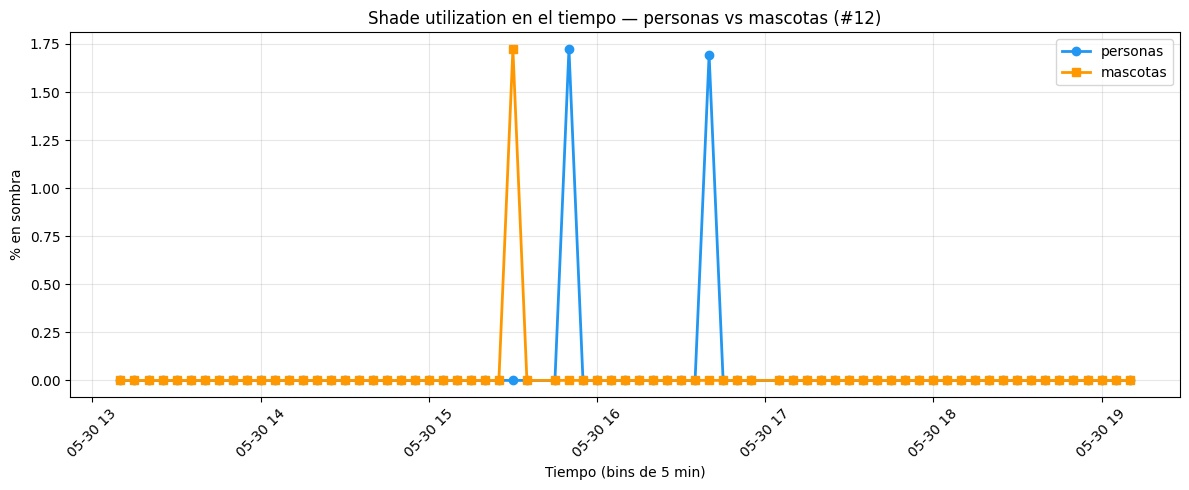

In [74]:
# shade utilization histórico (#12: separado personas/mascotas)
def calcular_shade_historico(df):
    """Evolución temporal de shade utilization. #12: personas y mascotas separados.
    Solo considera snapshots diurnos (donde shade es confiable)."""
    df_h = df.copy()

    # solo filas con dato de shade (diurnas); las None se excluyen del promedio
    df_h = df_h[df_h['shade_util_personas'].notna()].copy()
    if len(df_h) == 0:
        print('Sin snapshots diurnos con shade — nada que graficar')
        return None

    # agrupar por intervalos de 5 min (el dataset es de 1 hora, agrupar por hora daría 1 punto)
    df_h['bin'] = df_h['timestamp'].dt.floor('5min')
    agg = df_h.groupby('bin').agg(
        shade_personas=('shade_util_personas', 'mean'),
        shade_mascotas=('shade_util_mascotas', 'mean'),
        n=('shade_util_personas', 'size'),
    ).reset_index()

    plt.close('all')
    plt.figure(figsize=(12, 5))
    plt.plot(agg['bin'], agg['shade_personas']*100, marker='o',
             color='#2196F3', linewidth=2, label='personas')
    plt.plot(agg['bin'], agg['shade_mascotas']*100, marker='s',
             color='#FF9800', linewidth=2, label='mascotas')
    plt.xlabel('Tiempo (bins de 5 min)')
    plt.ylabel('% en sombra')
    plt.title('Shade utilization en el tiempo — personas vs mascotas (#12)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return agg

shade_historico = calcular_shade_historico(df_historico)

In [75]:
# ── Fase 6: evolución temporal de la vegetación ──────────────────────────────
# Compara el ExG promedio diario contra días previos. Enfoque temporal: el pasto
# secándose se ve como el ExG BAJANDO en el tiempo, sin depender de un umbral
# absoluto de "verde" (que variaría con cámara, luz y estación).

def analizar_vegetacion_temporal(df, ventana_dias=VENTANA_VEGETACION_DIAS):
    """
    Evolución del ExG del pasto por día. Compara el promedio reciente contra el
    período previo para detectar tendencia de secado.

    GUARD: solo compara períodos si hay al menos 2 días distintos. Con un solo día
    reporta el promedio pero no la tendencia (no hay contra qué comparar).
    Solo usa snapshots diurnos: el ExG depende mucho de la luz.
    """
    if 'exg_pasto_prom' not in df.columns:
        print('⏸️  Vegetación temporal DORMIDA — falta la columna exg_pasto_prom')
        return {'disponible': False, 'motivo': 'sin columna exg'}

    d = df[df['exg_pasto_prom'].notna()].copy()
    # solo diurnos: el ExG varía mucho con la luz, comparar peras con peras
    if 'condicion_luz' in d.columns:
        d = d[d['condicion_luz'] == 'diurno']
    if len(d) == 0:
        print('⏸️  Vegetación temporal DORMIDA — sin snapshots diurnos con ExG')
        return {'disponible': False, 'motivo': 'sin datos diurnos'}

    d['fecha'] = d['timestamp'].dt.date
    por_dia = d.groupby('fecha').agg(
        exg_prom=('exg_pasto_prom', 'mean'),
        n_snapshots=('exg_pasto_prom', 'size'),
    ).reset_index()

    print(f'ExG por día ({len(por_dia)} día(s) con datos diurnos):')
    for _, r in por_dia.iterrows():
        print(f'  {r["fecha"]}: ExG={r["exg_prom"]:.4f}  ({int(r["n_snapshots"])} snapshots)')

    resultado = {
        'disponible':   True,
        'n_dias':       len(por_dia),
        'exg_actual':   round(float(por_dia['exg_prom'].iloc[-1]), 4),
        'por_dia':      por_dia.to_dict(orient='records'),
        'tendencia':    None,
        'caida_rel':    None,
        'alerta_secado': False,
    }

    # GUARD: la tendencia necesita al menos 2 días
    if len(por_dia) < 2:
        print(f'⏸️  Tendencia DORMIDA — solo {len(por_dia)} día(s) de datos. '
              f'Se necesitan ≥2 días distintos para comparar (ideal: {ventana_dias}).')
        return resultado

    # comparar ventana reciente vs período previo
    reciente = por_dia.tail(ventana_dias)['exg_prom'].mean()
    previo   = por_dia.head(max(1, len(por_dia)-ventana_dias))['exg_prom'].mean()
    caida_rel = (previo - reciente) / previo if previo > 0 else 0.0

    resultado['tendencia']     = round(float(reciente - previo), 4)
    resultado['caida_rel']     = round(float(caida_rel), 4)
    resultado['alerta_secado'] = caida_rel > UMBRAL_CAIDA_EXG

    print(f'\n  ExG previo:   {previo:.4f}')
    print(f'  ExG reciente: {reciente:.4f}')
    print(f'  Caída relativa: {caida_rel*100:+.1f}%')
    if resultado['alerta_secado']:
        print(f'  ⚠️  ALERTA: caída >{UMBRAL_CAIDA_EXG*100:.0f}% — el pasto se está secando')
    else:
        print(f'  ✅ sin caída significativa (umbral {UMBRAL_CAIDA_EXG*100:.0f}%)')

    # gráfico de evolución
    plt.close('all')
    plt.figure(figsize=(11, 4))
    plt.plot(por_dia['fecha'], por_dia['exg_prom'], marker='o', color='#2e7d32', linewidth=2)
    plt.axhline(UMBRAL_EXG_VERDE, color='orange', linestyle='--', alpha=0.6,
                label=f'umbral verde ({UMBRAL_EXG_VERDE})')
    plt.xlabel('Fecha')
    plt.ylabel('ExG promedio (pasto)')
    plt.title('Evolución de la vegetación — ExG diario')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return resultado

vegetacion_temporal = analizar_vegetacion_temporal(df_historico)

ExG por día (1 día(s) con datos diurnos):
  2026-05-30: ExG=0.2301  (3961 snapshots)
⏸️  Tendencia DORMIDA — solo 1 día(s) de datos. Se necesitan ≥2 días distintos para comparar (ideal: 7).


In [76]:
# correlaciones (#28: solo sobre datos reales)
def calcular_correlaciones(df):
    """
    Correlación de Pearson entre pares de métricas meteorológicas y de uso.

    #28 GUARD DE DATOS: los sensores sintéticos son aleatorios → no correlacionan
    con nada por construcción. Esta métrica SOLO tiene sentido sobre datos reales.
    Si todo el histórico es sintético, se marca dormida.
    #15: se apoya en el flag datos_sinteticos.
    """
    # filtrar solo datos reales
    if 'datos_sinteticos' in df.columns:
        df_real = df[df['datos_sinteticos'] == False]
    else:
        df_real = df

    N_MINIMO = 250  # [AJUSTABLE] Schönbrodt & Perugini (2013): la muestra debe
    # acercarse a 250 para una correlación estable — 50 era un piso mínimo informal,
    # no el número de estabilidad real. https://doi.org/10.1016/j.jrp.2013.05.009
    
    if len(df_real) < N_MINIMO:
        print(f'⏸️  correlaciones DORMIDAS — solo {len(df_real)} snapshots reales '
              f'(se necesitan ≥{N_MINIMO}). Los sintéticos no correlacionan (#28).')
        return {'disponible': False, 'n_reales': len(df_real)}

    pares = [
        ('uv',         'shade_util_personas', 'UV vs Shade personas'),   # #12: nombre nuevo
        ('utci_valor', 'n_personas',          'UTCI vs N personas'),
        ('v',          'n_personas',          'Viento vs N personas'),
        ('lux',        'shade_util_personas', 'Lux vs Shade personas'),
    ]
    resultado = {'disponible': True, 'n_reales': len(df_real)}
    for col_a, col_b, etiqueta in pares:
        r     = round(df_real[col_a].corr(df_real[col_b]), 3)
        nivel = 'alta' if abs(r) > 0.7 else 'media' if abs(r) > 0.4 else 'baja'
        resultado[etiqueta] = {'r': r, 'nivel': nivel}
        print(f'  {etiqueta:<30} r={r:+.3f}  ({nivel})')
    return resultado

correlaciones = calcular_correlaciones(df_historico)

⏸️  correlaciones DORMIDAS — solo 0 snapshots reales (se necesitan ≥250). Los sintéticos no correlacionan (#28).


In [77]:
# guardar batch record
# [PROD] reemplazar CSV por tabla batch en PostgreSQL
RUTA_CSV_BATCH = 'batch.csv'
HEADERS_BATCH  = [
    'timestamp_batch', 'n_snapshots_procesados',
    'intervalo_real_seg',
    'n_snapshots_con_personas', 'presencia_continua_min',
    'activity_disponible', 'activity_personas', 'activity_mascotas',
    'uso_mobiliario_batch',
    'correlaciones_disponible', 'correlaciones',
    'exg_promedio_periodo',              # ← nuevo: vegetación del período
    'veg_disponible', 'veg_exg_actual', 'veg_alerta_secado',
    'area_observada_m2',                 # ← nuevo: contexto de la densidad
]

batch_record = {
    'timestamp_batch':          datetime.datetime.now().isoformat(),
    'n_snapshots_procesados':   len(df_historico),
    'intervalo_real_seg':       ocupacion['intervalo_real_seg'],
    'n_snapshots_con_personas': ocupacion['n_snapshots_con_personas'],
    'presencia_continua_min':   ocupacion['presencia_continua_min'],   # #27
    # #25: activity puede estar dormida
    'activity_disponible':      activity['disponible'],
    'activity_personas':        activity.get('personas'),
    'activity_mascotas':        activity.get('mascotas'),
    'uso_mobiliario_batch':     uso_batch,
    # #28: correlaciones puede estar dormida
    'correlaciones_disponible': correlaciones['disponible'],
    'correlaciones':            {k: v for k, v in correlaciones.items()
                                 if k not in ('disponible', 'n_reales')},
    'exg_promedio_periodo': round(float(df_historico['exg_pasto_prom'].mean()), 4)
                            if 'exg_pasto_prom' in df_historico.columns else None,
                            'veg_disponible':     vegetacion_temporal['disponible'],
    'veg_exg_actual':     vegetacion_temporal.get('exg_actual'),
    'veg_alerta_secado':  vegetacion_temporal.get('alerta_secado'),
    'area_observada_m2':    AREA_OBSERVADA_M2
}

init_csv(RUTA_CSV_BATCH, HEADERS_BATCH)
fila_batch = {
    campo: json.dumps(batch_record.get(campo), ensure_ascii=False)
           if isinstance(batch_record.get(campo), (dict, list))
           else batch_record.get(campo)
    for campo in HEADERS_BATCH
}
with open(RUTA_CSV_BATCH, 'a', newline='', encoding='utf-8') as f:
    csv.DictWriter(f, fieldnames=HEADERS_BATCH, quoting=csv.QUOTE_ALL).writerow(fila_batch)

print(f'✅ Batch guardado — {batch_record["timestamp_batch"]}')
print(f'   Snapshots procesados:  {batch_record["n_snapshots_procesados"]}')
print(f'   Intervalo real:        {batch_record["intervalo_real_seg"]}s')
print(f'   Presencia continua:    {batch_record["presencia_continua_min"]} min')
print(f'   Activity disponible:   {batch_record["activity_disponible"]}')
print(f'   Correlaciones disp.:   {batch_record["correlaciones_disponible"]}')

✅ CSV ya existe: batch.csv
✅ Batch guardado — 2026-07-22T13:31:44.455361
   Snapshots procesados:  3962
   Intervalo real:        5.0s
   Presencia continua:    6.8 min
   Activity disponible:   False
   Correlaciones disp.:   False


══════════════════════════════════════════════════════════════
  RESUMEN DEL BATCH — 3962 snapshots procesados
  Ventana: 2026-05-30 13:13 → 19:13
  Intervalo real (mediana): 5.0s
══════════════════════════════════════════════════════════════
  Personas por snapshot:  prom 0.58 · máx 6 · total detecciones 2294
  Mascotas por snapshot:  prom 0.18 · máx 4 · total detecciones 696
  Snapshots con gente:    1445 (36%)
  Presencia continua máx: 6.8 min
  UTCI:                   prom 31.0°C · rango 18.0–47.0°C
  Categoría UTCI típica:  estrés térmico moderado
  Sombra del parque:      prom 0.3% del suelo
  Vegetación (ExG):       prom 0.230
  Densidad:               prom 0.0000 usuarios/m² (umbral aglomeración 0.13)
  Área observada:         14814 m²
──────────────────────────────────────────────────────────────
  Guards → activity: dormida · correlaciones: dormidas
══════════════════════════════════════════════════════════════


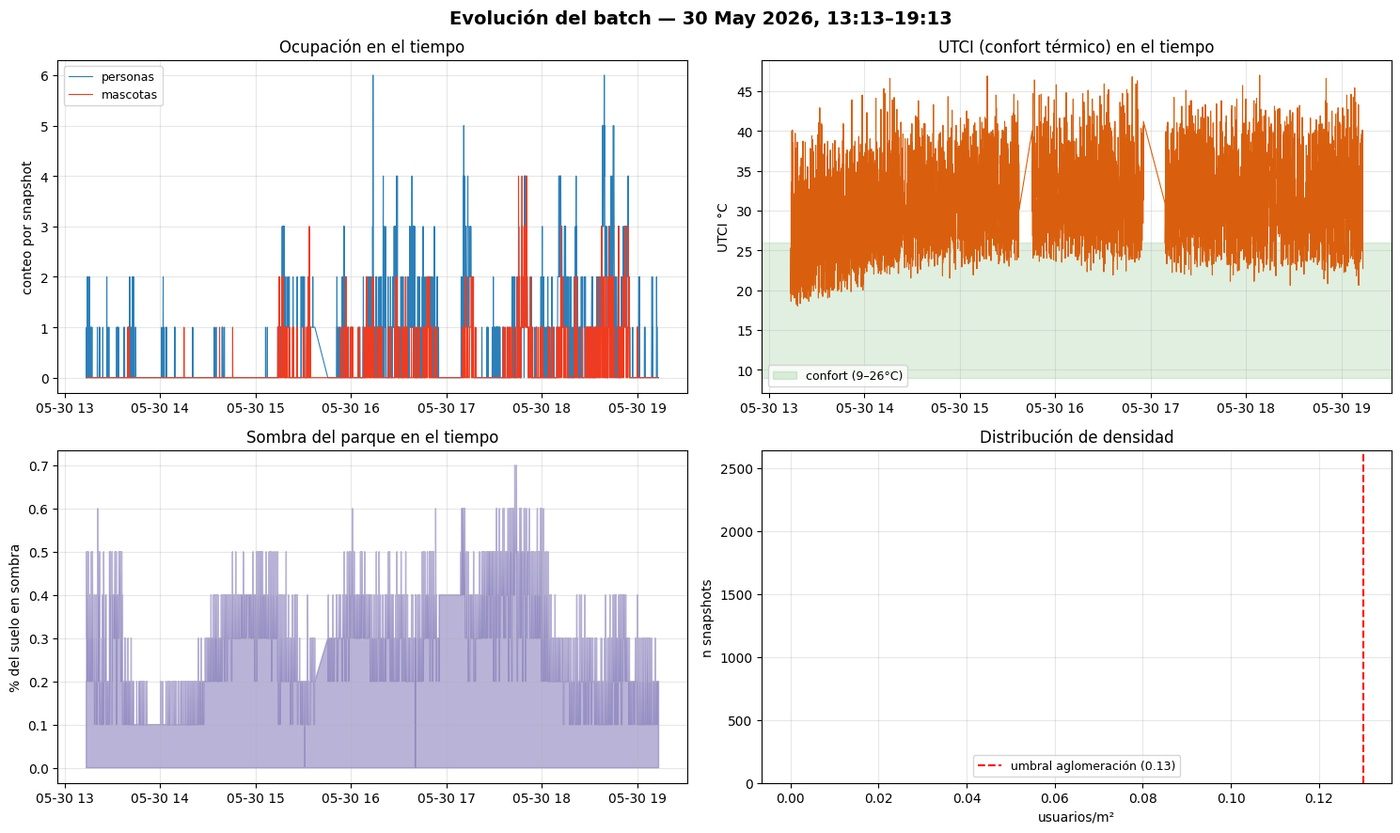

In [87]:
# ── RESUMEN VISUAL DEL BATCH ─────────────────────────────────────────────────
# Panel consolidado de todo lo procesado por el batch: estadísticas clave +
# evolución temporal de la tarde. Es la foto de conjunto que faltaba (había
# gráficos sueltos como shade/hora, pero ningún resumen integrado).

import matplotlib.pyplot as plt

df = df_historico.copy()
df = df.sort_values('timestamp')

# ── Bloque 1: estadísticas resumen en texto ──────────────────────────────────
print('═'*62)
print(f'  RESUMEN DEL BATCH — {len(df)} snapshots procesados')
print(f'  Ventana: {df["timestamp"].min():%Y-%m-%d %H:%M} → {df["timestamp"].max():%H:%M}')
print(f'  Intervalo real (mediana): {batch_record["intervalo_real_seg"]}s')
print('═'*62)

# conteos de personas/mascotas
print(f'  Personas por snapshot:  prom {df["n_personas"].mean():.2f} · '
      f'máx {df["n_personas"].max()} · total detecciones {int(df["n_personas"].sum())}')
print(f'  Mascotas por snapshot:  prom {df["n_mascotas"].mean():.2f} · '
      f'máx {df["n_mascotas"].max()} · total detecciones {int(df["n_mascotas"].sum())}')
print(f'  Snapshots con gente:    {ocupacion["n_snapshots_con_personas"]} '
      f'({100*ocupacion["n_snapshots_con_personas"]/len(df):.0f}%)')
print(f'  Presencia continua máx: {batch_record["presencia_continua_min"]} min')

# confort térmico
utci_validos = df['utci_valor'].dropna()
if len(utci_validos):
    print(f'  UTCI:                   prom {utci_validos.mean():.1f}°C · '
          f'rango {utci_validos.min():.1f}–{utci_validos.max():.1f}°C')
    cat_moda = df['utci_categoria'].mode()
    if len(cat_moda):
        print(f'  Categoría UTCI típica:  {cat_moda.iloc[0]}')

# sombra y vegetación
print(f'  Sombra del parque:      prom {100*df["shade_parque_pct"].mean():.1f}% del suelo')
if 'exg_pasto_prom' in df.columns and df['exg_pasto_prom'].notna().any():
    print(f'  Vegetación (ExG):       prom {df["exg_pasto_prom"].mean():.3f}')

# densidad y guards
print(f'  Densidad:               prom {df["densidad"].mean():.4f} usuarios/m² '
      f'(umbral aglomeración {UMBRAL_AGLOMERACION})')
print(f'  Área observada:         {batch_record["area_observada_m2"]:.0f} m²')
print('─'*62)
print(f'  Guards → activity: {"ACTIVA" if batch_record["activity_disponible"] else "dormida"} · '
      f'correlaciones: {"ACTIVAS" if batch_record["correlaciones_disponible"] else "dormidas"}')
print('═'*62)

# ── Bloque 2: panel de gráficos (evolución temporal de la tarde) ─────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle(f'Evolución del batch — {df["timestamp"].min():%d %b %Y}, '
             f'{df["timestamp"].min():%H:%M}–{df["timestamp"].max():%H:%M}',
             fontsize=14, fontweight='bold')

# (a) conteo de personas y mascotas en el tiempo
ax = axes[0, 0]
ax.plot(df['timestamp'], df['n_personas'], lw=0.8, color='#2c7fb8', label='personas')
ax.plot(df['timestamp'], df['n_mascotas'], lw=0.8, color='#f03b20', label='mascotas')
ax.set_title('Ocupación en el tiempo'); ax.set_ylabel('conteo por snapshot')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (b) UTCI en el tiempo, con banda de confort (9–26°C)
ax = axes[0, 1]
ax.plot(df['timestamp'], df['utci_valor'], lw=0.8, color='#d95f0e')
ax.axhspan(9, 26, alpha=0.12, color='green', label='confort (9–26°C)')
ax.set_title('UTCI (confort térmico) en el tiempo'); ax.set_ylabel('UTCI °C')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (c) sombra del parque en el tiempo
ax = axes[1, 0]
ax.fill_between(df['timestamp'], 100*df['shade_parque_pct'], color='#756bb1', alpha=0.5)
ax.set_title('Sombra del parque en el tiempo'); ax.set_ylabel('% del suelo en sombra')
ax.grid(alpha=0.3)

# (d) distribución de densidad, con umbral de aglomeración
ax = axes[1, 1]
ax.hist(df['densidad'].dropna(), bins=30, color='#41ab5d', alpha=0.8)
ax.axvline(UMBRAL_AGLOMERACION, color='red', ls='--', lw=1.5,
           label=f'umbral aglomeración ({UMBRAL_AGLOMERACION})')
ax.set_title('Distribución de densidad'); ax.set_xlabel('usuarios/m²')
ax.set_ylabel('n snapshots'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

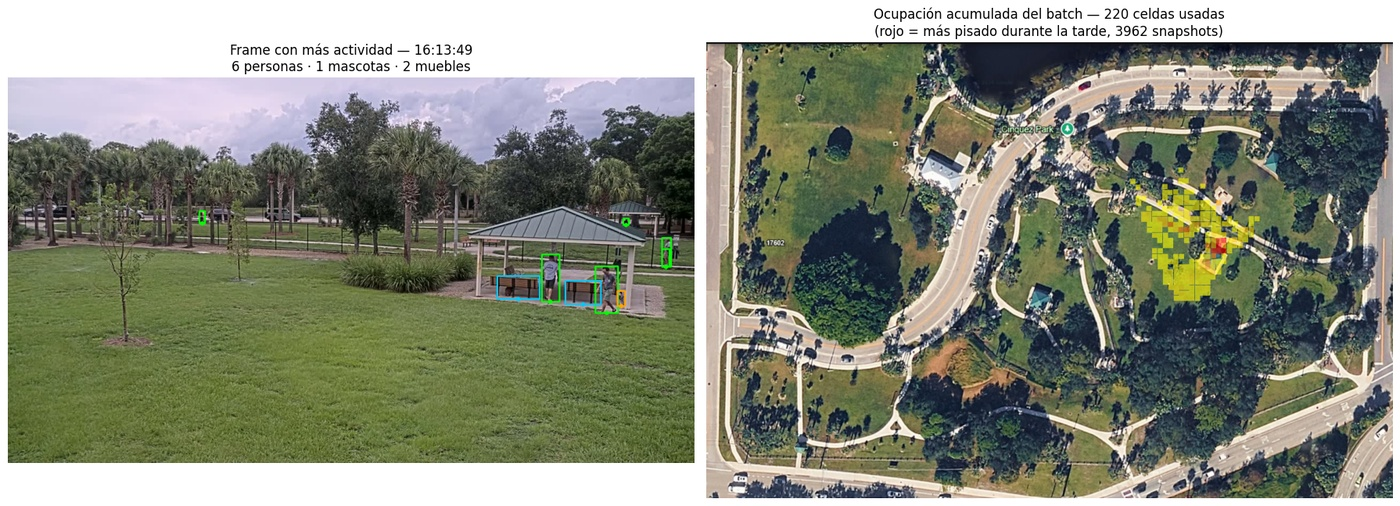

Frame de ejemplo: 20260530_161349.jpg (el de mayor conteo, 6 personas)
Celdas más usadas (metros, conteo acumulado):
 centro_m_x  centro_m_y  n_total
      19.07       14.83      130
      19.07       10.83      130
      17.07       12.83      129


In [90]:
# ── RESUMEN VISUAL SOBRE EL PARQUE ───────────────────────────────────────────
# Dos vistas sobre las imágenes reales (no gráficos abstractos):
#  IZQUIERDA: un frame de ejemplo con sus detecciones dibujadas — "así ve el
#             sistema un instante" (personas, mascotas, mobiliario).
#  DERECHA:   mapa de ocupación ACUMULADO de todo el batch sobre el satelital —
#             "dónde se paró la gente durante toda la tarde" (objetivo 2, doc 07).

import matplotlib.pyplot as plt
import numpy as np
import os

df = df_historico.copy()
idx_lleno = df['n_personas'].idxmax()
ts_lleno = df.loc[idx_lleno, 'timestamp']
nombre_frame = ts_lleno.strftime('%Y%m%d_%H%M%S') + '.jpg'
ruta_frame = f'{CARPETA_FRAMES}{nombre_frame}'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ── IZQUIERDA: frame con detecciones (dibujadas acá, no con visualizar_bboxes
#    que hace su propio plt.figure y no devuelve la imagen) ──────────────────
if os.path.exists(ruta_frame):
    img = cargar_imagen_local(ruta_frame)
    dets = correr_yolo(img, modelo_yolo)
    img_anotado = img.copy()
    colores = {'personas': COLOR_PERSONA, 'mascotas': COLOR_MASCOTA,
               'mobiliario': COLOR_MOBILIARIO_LIBRE}
    for cat, color in colores.items():
        for d in dets[cat]:
            x1, y1, x2, y2 = d['bbox']
            cv2.rectangle(img_anotado, (x1, y1), (x2, y2), color, 2)
            cv2.circle(img_anotado, d['pie'], 4, color, -1)
    ax1.imshow(cv2.cvtColor(img_anotado, cv2.COLOR_BGR2RGB))
    ax1.set_title(f'Frame con más actividad — {ts_lleno:%H:%M:%S}\n'
                  f'{len(dets["personas"])} personas · {len(dets["mascotas"])} mascotas · '
                  f'{len(dets["mobiliario"])} muebles', fontsize=12)
else:
    ax1.text(0.5, 0.5, f'Frame {nombre_frame}\nno encontrado en disco',
             ha='center', va='center', transform=ax1.transAxes)
ax1.axis('off')

# ── DERECHA: mapa de ocupación acumulado sobre el satelital ──────────────────
grilla = construir_grilla_ocupacion(df)
sat = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()

if grilla is not None and len(grilla) > 0:
    overlay = sat.copy()
    p0 = np.array(metros_a_satelital((0, 0), H_METROS_SAT), dtype=float)
    p1 = np.array(metros_a_satelital((1, 0), H_METROS_SAT), dtype=float)
    lado_px = max(2, int(KMEANS_TAM_CELDA_M * np.linalg.norm(p1 - p0)))
    conteo_max = grilla['n_total'].max()

    for _, celda in grilla.iterrows():
        cx, cy = metros_a_satelital((celda['centro_m_x'], celda['centro_m_y']), H_METROS_SAT)
        frac = celda['n_total'] / conteo_max
        color = (255, int(255*(1-frac)), 0)  # rojo=más usado, amarillo=menos
        x1, y1 = cx - lado_px//2, cy - lado_px//2
        cv2.rectangle(overlay, (x1, y1), (x1+lado_px, y1+lado_px), color, -1)
    sat = cv2.addWeighted(overlay, 0.6, sat, 0.4, 0)
    ax2.imshow(sat)
    ax2.set_title(f'Ocupación acumulada del batch — {len(grilla)} celdas usadas\n'
                  f'(rojo = más pisado durante la tarde, {len(df)} snapshots)', fontsize=12)
else:
    ax2.imshow(sat)
    ax2.set_title('Sin ocupación acumulada suficiente para el mapa', fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f'Frame de ejemplo: {nombre_frame} (el de mayor conteo, {df.loc[idx_lleno,"n_personas"]} personas)')
if grilla is not None and len(grilla) > 0:
    top = grilla.nlargest(3, 'n_total')[['centro_m_x', 'centro_m_y', 'n_total']]
    print('Celdas más usadas (metros, conteo acumulado):')
    print(top.to_string(index=False))

#### FASE 7: kmeans

In [78]:
# ── FASE 7 · ESCENARIO 2: clustering temporal (regímenes de uso) ──────────────
# Clusteriza SNAPSHOTS en el tiempo (no zonas). Encuentra momentos con patrones
# de uso distintos (ej. tranquilo vs concurrido). Reemplaza el KMeans de 6 zonas
# (#30: estadísticamente vacío). Requiere volumen de datos reales para significar.

def preparar_features_temporales(df):
    """Una fila por snapshot con features de uso/confort para clustering temporal."""
    feats = pd.DataFrame({
        'n_personas':   df['n_personas'],
        'n_mascotas':   df['n_mascotas'],
        'utci_valor':   df['utci_valor'],
        # shade puede ser None (no diurno) → rellenar con 0 para el clustering
        'shade_parque': df['shade_parque_pct'].fillna(0),
        'hora':         df['timestamp'].dt.hour + df['timestamp'].dt.minute/60,
    })
    return feats

features_temporales = preparar_features_temporales(df_historico)
print(f'Features temporales: {features_temporales.shape[0]} snapshots × {features_temporales.shape[1]} features')
print(features_temporales.describe().round(2).to_string())

Features temporales: 3962 snapshots × 5 features
       n_personas  n_mascotas  utci_valor  shade_parque     hora
count     3962.00     3962.00     3962.00       3962.00  3962.00
mean         0.58        0.18       31.04          0.00    16.20
std          0.91        0.48        5.88          0.00     1.78
min          0.00        0.00       18.00          0.00    13.22
25%          0.00        0.00       26.12          0.00    14.62
50%          0.00        0.00       30.60          0.00    16.18
75%          1.00        0.00       35.70          0.00    17.80
max          6.00        4.00       47.00          0.01    19.22


In [79]:
# ── Escenario 2: correr KMeans temporal (con guard de datos) ──────────────────

def correr_kmeans_temporal(df, features):
    """
    Clusteriza snapshots en regímenes de uso.
    GUARD (#28/#30): requiere >= KMEANS_N_MINIMO snapshots reales. Con pocos datos
    o datos sintéticos, los clusters no significan patrones reales → dormido.
    """
    # guard 1: datos reales
    n_reales = int((~df['datos_sinteticos']).sum()) if 'datos_sinteticos' in df.columns else len(df)
    if n_reales < KMEANS_N_MINIMO:
        print(f'⏸️  KMeans temporal DORMIDO — solo {n_reales} snapshots reales '
              f'(se necesitan ≥{KMEANS_N_MINIMO}). Con datos sintéticos los clusters '
              f'agrupan ruido, no patrones reales (#30).')
        return None

    # guard 2: variabilidad — features constantes no aportan
    features_utiles = features.loc[:, features.std() > 1e-6]
    if features_utiles.shape[1] < 2:
        print(f'⏸️  KMeans temporal DORMIDO — solo {features_utiles.shape[1]} feature(s) '
              f'con variación. El resto son constantes (ver describe arriba).')
        return None

    # (solo llega aquí con datos reales suficientes y variados)
    X = StandardScaler().fit_transform(features_utiles.values)
    km = KMeans(n_clusters=KMEANS_N_CLUSTERS_TEMPORAL, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    df_result = df.copy()
    df_result['regimen'] = labels
    # ordenar regímenes por concurrencia (n_personas promedio) para etiquetar
    orden = df_result.groupby('regimen')['n_personas'].mean().sort_values().index
    mapa  = {viejo: nuevo for nuevo, viejo in enumerate(orden)}
    df_result['regimen'] = df_result['regimen'].map(mapa)

    print(f'✅ KMeans temporal: {KMEANS_N_CLUSTERS_TEMPORAL} regímenes sobre {n_reales} snapshots')
    resumen = df_result.groupby('regimen').agg(
        n_snapshots=('regimen', 'size'),
        personas_prom=('n_personas', 'mean'),
        utci_prom=('utci_valor', 'mean'),
    ).round(2)
    print(resumen.to_string())
    return df_result

resultado_kmeans_temporal = correr_kmeans_temporal(df_historico, features_temporales)

⏸️  KMeans temporal DORMIDO — solo 0 snapshots reales (se necesitan ≥100). Con datos sintéticos los clusters agrupan ruido, no patrones reales (#30).


In [80]:
# ── FASE 7 · ESCENARIO 1: grilla espacial (mapa de ocupación) ────────────────
# Con homografía disponible: divide el parque en celdas de metros reales y acumula
# la ocupación de todos los snapshots. La literatura clusteriza sobre MUCHAS celdas
# (Changsha: 121 plots), no sobre 6 muebles (#30).
#
# ALCANCE ACTUAL: mapa de OCUPACIÓN (dónde se para la gente). El mapa de islas de
# calor UTCI por celda requiere sombra por celda — ver nota al final.

def construir_grilla_ocupacion(df, tam_celda_m=KMEANS_TAM_CELDA_M):
    """Acumula posiciones (pos_m) de todos los snapshots en una grilla de celdas.
    Devuelve DataFrame con una fila por celda ocupada."""
    puntos_p, puntos_m = [], []
    for col, destino in [('pos_m_personas', puntos_p), ('pos_m_mascotas', puntos_m)]:
        if col not in df.columns:
            continue
        for lista in df[col]:
            if isinstance(lista, list):
                destino.extend([p for p in lista if p])

    if not puntos_p and not puntos_m:
        return None

    todos = puntos_p + puntos_m

    N_DETECCIONES_MINIMO = 50  # [AJUSTABLE] asíntota de estimación de home range/KDE
    # (Seaman et al. 1999; Tarjan & Tinker 2016, PLOS ONE) — bajo esto, el mapa de
    # ocupación es ruido de pocas detecciones, no un patrón real. Analogía de otro
    # dominio (ecología de movimiento), no un estudio hecho sobre este caso puntual.
    if len(todos) < N_DETECCIONES_MINIMO:
        print(f'⏸️  Grilla de ocupación DORMIDA — solo {len(todos)} detecciones '
              f'(se necesitan ≥{N_DETECCIONES_MINIMO} para que el mapa no sea ruido).')
        return None

    xs = [p[0] for p in todos]; ys = [p[1] for p in todos]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    def celda_de(p):
        return (int((p[0]-x_min)//tam_celda_m), int((p[1]-y_min)//tam_celda_m))

    conteo = {}
    for p in puntos_p:
        c = celda_de(p); conteo.setdefault(c, {'personas':0,'mascotas':0})['personas'] += 1
    for p in puntos_m:
        c = celda_de(p); conteo.setdefault(c, {'personas':0,'mascotas':0})['mascotas'] += 1

    filas = []
    for (ix, iy), v in conteo.items():
        filas.append({
            'celda_x': ix, 'celda_y': iy,
            'centro_m_x': round(x_min + (ix+0.5)*tam_celda_m, 2),
            'centro_m_y': round(y_min + (iy+0.5)*tam_celda_m, 2),
            'n_personas': v['personas'], 'n_mascotas': v['mascotas'],
            'n_total': v['personas'] + v['mascotas'],
        })
    return pd.DataFrame(filas)


def kmeans_grilla_espacial(df, tam_celda_m=KMEANS_TAM_CELDA_M, n_clusters=3):
    """
    Clusteriza celdas de la grilla por intensidad de uso.
    GUARD: requiere suficientes celdas ocupadas para que el clustering signifique algo.
    """
    grilla = construir_grilla_ocupacion(df, tam_celda_m)
    if grilla is None or len(grilla) == 0:
        print('⏸️  Grilla espacial DORMIDA — sin posiciones proyectadas en el histórico.')
        return None

    N_CELDAS_MINIMO = 20   # [AJUSTABLE] bajo esto, clusterizar no aporta sobre ordenar
    if len(grilla) < N_CELDAS_MINIMO:
        print(f'⏸️  KMeans grilla DORMIDO — solo {len(grilla)} celdas ocupadas '
              f'(se necesitan ≥{N_CELDAS_MINIMO} para que los clusters signifiquen algo).')
        print('   La grilla de ocupación SÍ está disponible para visualizar.')
        return grilla   # devuelve la grilla aunque no clusterice

    X = StandardScaler().fit_transform(grilla[['n_personas','n_mascotas','n_total']].values)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    grilla['cluster'] = km.fit_predict(X)
    orden = grilla.groupby('cluster')['n_total'].mean().sort_values().index
    mapa  = {v: i for i, v in enumerate(orden)}
    grilla['cluster'] = grilla['cluster'].map(mapa)
    print(f'✅ KMeans grilla: {n_clusters} niveles de uso sobre {len(grilla)} celdas '
          f'de {tam_celda_m}×{tam_celda_m} m')
    return grilla

# NOTA sobre islas de calor térmicas:
# Para un mapa de UTCI POR CELDA haría falta sombra por celda — proyectando la
# máscara de sombra al plano de metros. Es factible y es el siguiente paso natural.
# Hoy el UTCI es global por snapshot (sensores únicos), así que un "mapa de UTCI"
# sería uniforme y engañoso (#29, #32).

resultado_grilla = kmeans_grilla_espacial(df_historico)

✅ KMeans grilla: 3 niveles de uso sobre 220 celdas de 2×2 m


In [81]:
# ── FASE 7 · ESCENARIO 3: mapa de islas de calor UTCI por celda ──────────────
# Objetivo 1 del proyecto en su forma completa (doc 05/07): en vez de UN UTCI
# global por snapshot, un UTCI POR CELDA de 2×2 m, para ver dónde del parque pega
# más el calor. Es lo que las municipalidades realmente usan para decidir dónde
# plantar árboles o poner sombra (Dresden, Tel Aviv, Lisboa — doc 07).
#
# CÓMO: el modelo de mrt (calcular_tr) predice temperatura radiante REGIONAL a
# cielo abierto. La cámara mide sombra LOCAL. Se combinan por celda con la misma
# interpolación sol/sombra de calcular_y_clasificar_utci global (doc 04):
#     mrt_sol    = modelo(radiación de cielo despejado COMPLETA)
#     mrt_sombra = modelo(radiación × FRACCION_DIFUSA)   # solo la difusa
#     mrt_celda  = mrt_sombra + (1 - sombra_celda) × (mrt_sol - mrt_sombra)
# donde sombra_celda ∈ [0,1] es la fracción de esa celda que está en sombra,
# obtenida proyectando la máscara de sombra (píxeles de cámara) al plano de metros.
#
# ALCANCE HONESTO (doc 04, "limitación honesta"): el mapa es de CONTRASTE TÉRMICO
# RELATIVO — dónde hace más o menos calor comparativamente. El contraste sol/sombra
# es real y grande (varios °C). El VALOR ABSOLUTO de una celda a la sombra tiene un
# sesgo conocido: el suelo soleado alrededor sigue irradiando onda larga, cosa que
# el modelo (entrenado sobre "sombra = día nublado") no captura. Mismo trato que
# viento_es_real: se marca con un flag (utci_celda_es_relativa), no se pretende que
# sea una medición absoluta por punto. Ver doc 04 y doc 06.
#
# NIVEL 1 (esto): mapa por snapshot — la primitiva, útil y verificable desde el
# primer frame diurno con sombra. NIVEL 2 (documentado, dormido, doc 05/06):
# agregación a horas representativas (mañana/mediodía/tarde) e intersección de
# hotspots consistentes entre días (método Dresden) — necesita varios días de
# datos reales, madura con el tiempo como VCI. No se implementa hoy.

FRACCION_DIFUSA = 0.15  # [AJUSTABLE] fracción difusa típica bajo cielo despejado
# (doc 04): a la sombra se bloquea el haz directo pero la difusa del cielo sigue
# llegando. Mismo valor que usaría el ajuste sol/sombra global.

UMBRAL_SOMBRA_TRIVIAL = 0.05  # [AJUSTABLE] si <5% o >95% del suelo está en sombra,
# no hay contraste sol/sombra que mapear → mapa dormido (guard 2).


def sombra_por_celda(mascara_sombra, H, tam_celda_m=KMEANS_TAM_CELDA_M,
                     horizonte_y=HORIZONTE_SUELO_Y):
    """Proyecta la máscara de sombra al plano de metros y calcula, por celda de
    tam_celda_m × tam_celda_m, la fracción de suelo que está en sombra.

    Devuelve dict {(celda_x, celda_y): fraccion_sombra ∈ [0,1]} y los límites
    (x_min, y_min) usados, para que el UTCI por celda y la grilla de ocupación
    compartan el mismo origen de celdas.

    Vectorizado: proyecta todos los píxeles de suelo de una vez (cv2 punto a
    punto sobre ~900k píxeles sería inviable). Verificado idéntico al
    proyectar_a_metros individual.
    """
    alto, ancho = mascara_sombra.shape
    # solo píxeles bajo el horizonte (el resto es cielo/fondo, no es suelo)
    ys, xs = np.mgrid[horizonte_y:alto, 0:ancho]
    xs = xs.ravel(); ys = ys.ravel()
    sombra_flat = mascara_sombra[horizonte_y:, :].ravel()

    # proyección vectorizada píxel → metros
    pts_px = np.stack([xs, ys], axis=1).astype(np.float32)[None, :, :]  # (1,N,2)
    pts_m = cv2.perspectiveTransform(pts_px, H)[0]                       # (N,2)

    # descartar proyecciones no confiables (más allá del rango, cerca del horizonte)
    dist = np.hypot(pts_m[:, 0], pts_m[:, 1])
    ok = dist <= DISTANCIA_MAX_CONFIABLE_M
    pts_m = pts_m[ok]; sombra_flat = sombra_flat[ok]
    if len(pts_m) == 0:
        return {}, None

    x_min = pts_m[:, 0].min(); y_min = pts_m[:, 1].min()
    cx = ((pts_m[:, 0] - x_min) // tam_celda_m).astype(int)
    cy = ((pts_m[:, 1] - y_min) // tam_celda_m).astype(int)

    # por celda: fracción de píxeles en sombra = media de la máscara binaria
    suma = {}    # (cx,cy) -> [px_en_sombra, px_totales]
    for i in range(len(cx)):
        k = (int(cx[i]), int(cy[i]))
        s = suma.setdefault(k, [0, 0])
        s[0] += int(sombra_flat[i]); s[1] += 1
    fraccion = {k: (v[0] / v[1]) for k, v in suma.items() if v[1] > 0}
    return fraccion, (float(x_min), float(y_min))


def mapa_utci_por_celda(sensor_data, mascara_sombra, condicion_luz, H,
                        tam_celda_m=KMEANS_TAM_CELDA_M):
    """Mapa de islas de calor UTCI: un UTCI por celda de 2×2 m, ajustado por la
    sombra local de cada celda. Nivel 1 (por snapshot).

    GUARD (doc 05 principio 1 — métrica dormida antes que métrica falsa): solo
    tiene sentido en condición 'diurno' con sombra no trivial. De noche/nublado
    la máscara es todo ceros → el mapa saldría uniforme (correcto, pero sin
    información) → dormido.

    Devuelve DataFrame con una fila por celda: centro en metros, fracción de
    sombra, mrt y UTCI de esa celda, categoría, y el flag utci_celda_es_relativa.
    None si el guard no se cumple.
    """
    # --- guard 1: condición de luz diurna ---
    if condicion_luz != 'diurno':
        print(f'⏸️  Mapa de calor UTCI DORMIDO — condición "{condicion_luz}" '
              f'(sin sol, la sombra local no discrimina nada).')
        return None

    fraccion, origen = sombra_por_celda(mascara_sombra, H, tam_celda_m)

    # --- guard 2: sombra no trivial (si no hay contraste, no hay isla de calor) ---
    if not fraccion:
        print('⏸️  Mapa de calor UTCI DORMIDO — sin suelo proyectable en rango.')
        return None
    sombra_media = float(np.mean(list(fraccion.values())))
    if sombra_media < UMBRAL_SOMBRA_TRIVIAL or sombra_media > (1 - UMBRAL_SOMBRA_TRIVIAL):
        print(f'⏸️  Mapa de calor UTCI DORMIDO — sombra casi uniforme '
              f'({sombra_media:.2%} del suelo). Sin contraste sol/sombra que mapear.')
        return None

    # --- mrt en los dos regímenes extremos, UNA vez por snapshot (no por celda) ---
    tdb = sensor_data['tdb']; rh = sensor_data['rh']
    ts = datetime.datetime.fromisoformat(sensor_data['timestamp'])
    viento, viento_es_real = obtener_viento(ts, sensor_data.get('v'))
    v_utci = float(np.clip(viento, *UTCI_RANGO_V))

    elev = elevacion_solar(ts)
    rad_sol = radiacion_cielo_despejado(elev)
    hora_local = (ts.hour + UTC_OFFSET_MODELO) % 24
    dia = ts.timetuple().tm_yday
    base = {
        't2m_c': tdb, 'rh': rh, 'viento': viento,
        'elev_solar': elev,
        'hora_sin': np.sin(2*np.pi*hora_local/24), 'hora_cos': np.cos(2*np.pi*hora_local/24),
        'dia_sin':  np.sin(2*np.pi*dia/365),       'dia_cos':  np.cos(2*np.pi*dia/365),
    }

    def _mrt_con_radiacion(rad):
        vals = dict(base, rad_cielo_despejado=rad)
        X = np.array([[vals[f] for f in FEATURES_MODELO_MRT]])
        return float(MODELO_MRT.predict(SCALER_MRT.transform(X))[0])

    mrt_sol    = _mrt_con_radiacion(rad_sol)
    mrt_sombra = _mrt_con_radiacion(rad_sol * FRACCION_DIFUSA)

    # --- por celda: interpolar mrt según su sombra local, calcular UTCI ---
    x_min, y_min = origen
    filas = []
    for (ix, iy), frac in fraccion.items():
        mrt_celda = mrt_sombra + (1 - frac) * (mrt_sol - mrt_sombra)
        utci_celda = round(float(utci(tdb=tdb, tr=round(mrt_celda, 2),
                                      v=v_utci, rh=rh).utci), 2)
        filas.append({
            'celda_x': ix, 'celda_y': iy,
            'centro_m_x': round(x_min + (ix+0.5)*tam_celda_m, 2),
            'centro_m_y': round(y_min + (iy+0.5)*tam_celda_m, 2),
            'sombra_frac':  round(frac, 3),
            'mrt_celda':    round(mrt_celda, 2),
            'utci_celda':   utci_celda,
            'utci_categoria': clasificar_utci(utci_celda),
        })

    df_mapa = pd.DataFrame(filas)
    df_mapa.attrs['utci_celda_es_relativa'] = True     # ver alcance honesto arriba
    df_mapa.attrs['viento_es_real'] = viento_es_real
    df_mapa.attrs['mrt_sol'] = round(mrt_sol, 2)
    df_mapa.attrs['mrt_sombra'] = round(mrt_sombra, 2)

    rango = df_mapa['utci_celda'].max() - df_mapa['utci_celda'].min()
    print(f'✅ Mapa de calor UTCI: {len(df_mapa)} celdas de {tam_celda_m}×{tam_celda_m} m · '
          f'UTCI {df_mapa["utci_celda"].min():.1f}–{df_mapa["utci_celda"].max():.1f}°C '
          f'(contraste {rango:.1f}°C) · sombra media {sombra_media:.0%}')
    print(f'   ⚠️  valores RELATIVOS (contraste), no medición absoluta por celda — '
          f'flag utci_celda_es_relativa (doc 04/06)')
    return df_mapa


# se calcula sobre el snapshot individual (el mismo que ya tiene mascara_sombra
# y condicion_luz en memoria de la fase de sombra), no sobre el batch histórico
resultado_mapa_calor = mapa_utci_por_celda(
    sensor_data, mascara_sombra, condicion_luz, H_HOMOGRAFIA)

⏸️  Mapa de calor UTCI DORMIDO — sombra casi uniforme (0.04% del suelo). Sin contraste sol/sombra que mapear.


In [82]:
# ── Visualizar mapa de islas de calor UTCI sobre el satelital ────────────────
# Colores OFICIALES del estándar UTCI (Bröde et al.): cada categoría de estrés
# térmico con su color. Las bandas del estándar son de ~6°C, más anchas que el
# sesgo de onda larga (<1°C, doc 04) → el color casi nunca salta de categoría por
# ese sesgo, así que la vista oficial es robusta. El flag utci_celda_es_relativa
# sigue puesto: el CONTRASTE entre zonas es lo confiable, no el valor por punto.

COLOR_UTCI = {   # RGB, paleta estándar UTCI (rojo=calor, verde=confort, azul=frío)
    'estrés térmico extremo':       (153,   0,   0),
    'estrés térmico muy fuerte':    (204,   0,   0),
    'estrés térmico fuerte':        (255,  51,   0),
    'estrés térmico moderado':      (255, 153,  51),
    'sin estrés térmico':           ( 51, 160,  44),   # confortable
    'leve estrés por frío':         (166, 206, 227),
    'estrés por frío moderado':     ( 51, 153, 255),
    'estrés por frío fuerte':       (  0,  76, 204),
    'estrés por frío muy fuerte':   (  0,  38, 153),
    'estrés por frío extremo':      (  0,   0, 102),
}

if resultado_mapa_calor is not None and len(resultado_mapa_calor) > 0:
    sat_calor = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()
    overlay   = sat_calor.copy()

    # escala metros → píxeles de satelital (mismo método que la grilla de ocupación)
    p0 = np.array(metros_a_satelital((0, 0), H_METROS_SAT), dtype=float)
    p1 = np.array(metros_a_satelital((1, 0), H_METROS_SAT), dtype=float)
    px_por_m = np.linalg.norm(p1 - p0)
    lado_px  = max(2, int(KMEANS_TAM_CELDA_M * px_por_m))

    for _, celda in resultado_mapa_calor.iterrows():
        cx, cy = metros_a_satelital((celda['centro_m_x'], celda['centro_m_y']), H_METROS_SAT)
        # color oficial de la categoría; gris si apareciera una etiqueta inesperada
        color = COLOR_UTCI.get(celda['utci_categoria'], (128, 128, 128))
        x1, y1 = cx - lado_px//2, cy - lado_px//2
        cv2.rectangle(overlay, (x1, y1), (x1+lado_px, y1+lado_px), color, -1)

    sat_calor = cv2.addWeighted(overlay, 0.55, sat_calor, 0.45, 0)

    # leyenda: solo las categorías que aparecen en este mapa
    cats_presentes = [e for _, e in UTCI_CORTES
                      if e in set(resultado_mapa_calor['utci_categoria'])]
    parches = [patches.Patch(color=np.array(COLOR_UTCI[e])/255, label=e)
               for e in cats_presentes]

    plt.close('all')
    plt.figure(figsize=(13, 9))
    plt.imshow(sat_calor)
    rango = resultado_mapa_calor['utci_celda'].max() - resultado_mapa_calor['utci_celda'].min()
    plt.title(f'Mapa de islas de calor UTCI — {len(resultado_mapa_calor)} celdas de '
              f'{KMEANS_TAM_CELDA_M}×{KMEANS_TAM_CELDA_M} m (snapshot único)\n'
              f'colores = categoría oficial UTCI · contraste {rango:.1f}°C · '
              f'valores RELATIVOS (contraste), no medición absoluta por celda',
              fontsize=11)
    plt.legend(handles=parches, loc='center left', bbox_to_anchor=(1, 0.5),
               fontsize=9, title='Categoría UTCI')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print('Celdas más calurosas:')
    cols = ['centro_m_x', 'centro_m_y', 'sombra_frac', 'utci_celda', 'utci_categoria']
    print(resultado_mapa_calor.nlargest(5, 'utci_celda')[cols].to_string(index=False))
    print('\nCeldas más frescas:')
    print(resultado_mapa_calor.nsmallest(5, 'utci_celda')[cols].to_string(index=False))
else:
    print('Sin mapa de calor para visualizar (guard: requiere día con sombra no trivial)')

Sin mapa de calor para visualizar (guard: requiere día con sombra no trivial)


In [83]:
# guardar resultado KMeans
# [PROD] reemplazar CSV por tabla kmeans en PostgreSQL
RUTA_CSV_KMEANS = 'kmeans.csv'
HEADERS_KMEANS  = [
    'timestamp_kmeans',
    'temporal_disponible', 'n_regimenes', 'regimenes',
    'grilla_disponible', 'n_celdas', 'grilla_clusterizada', 'tam_celda_m',
    'n_snapshots_usados',
]

temporal_ok = resultado_kmeans_temporal is not None
# la grilla puede existir (celdas) aunque no se haya clusterizado (pocas celdas)
grilla_ok   = resultado_grilla is not None and len(resultado_grilla) > 0
grilla_clust = grilla_ok and 'cluster' in resultado_grilla.columns

regimenes_data = None
n_regimenes = None
if temporal_ok:
    n_regimenes = KMEANS_N_CLUSTERS_TEMPORAL
    regimenes_data = resultado_kmeans_temporal.groupby('regimen').agg(
        n=('regimen', 'size'),
        personas_prom=('n_personas', 'mean'),
        utci_prom=('utci_valor', 'mean'),
    ).round(2).to_dict(orient='index')

kmeans_record = {
    'timestamp_kmeans':    datetime.datetime.now().isoformat(),
    'temporal_disponible': temporal_ok,
    'n_regimenes':         n_regimenes,
    'regimenes':           regimenes_data,
    'grilla_disponible':   grilla_ok,
    'n_celdas':            int(len(resultado_grilla)) if grilla_ok else 0,
    'grilla_clusterizada': grilla_clust,
    'tam_celda_m':         KMEANS_TAM_CELDA_M,
    'n_snapshots_usados':  len(df_historico),
}

init_csv(RUTA_CSV_KMEANS, HEADERS_KMEANS)
fila_kmeans = {
    campo: json.dumps(kmeans_record.get(campo), ensure_ascii=False)
           if isinstance(kmeans_record.get(campo), (dict, list))
           else kmeans_record.get(campo)
    for campo in HEADERS_KMEANS
}
with open(RUTA_CSV_KMEANS, 'a', newline='', encoding='utf-8') as f:
    csv.DictWriter(f, fieldnames=HEADERS_KMEANS, quoting=csv.QUOTE_ALL).writerow(fila_kmeans)

print(f'✅ KMeans guardado — {kmeans_record["timestamp_kmeans"]}')
print(f'   Temporal disponible:  {temporal_ok}')
print(f'   Grilla disponible:    {grilla_ok} ({kmeans_record["n_celdas"]} celdas)')
print(f'   Grilla clusterizada:  {grilla_clust}')

✅ CSV ya existe: kmeans.csv
✅ KMeans guardado — 2026-07-22T13:31:46.490775
   Temporal disponible:  False
   Grilla disponible:    True (220 celdas)
   Grilla clusterizada:  True


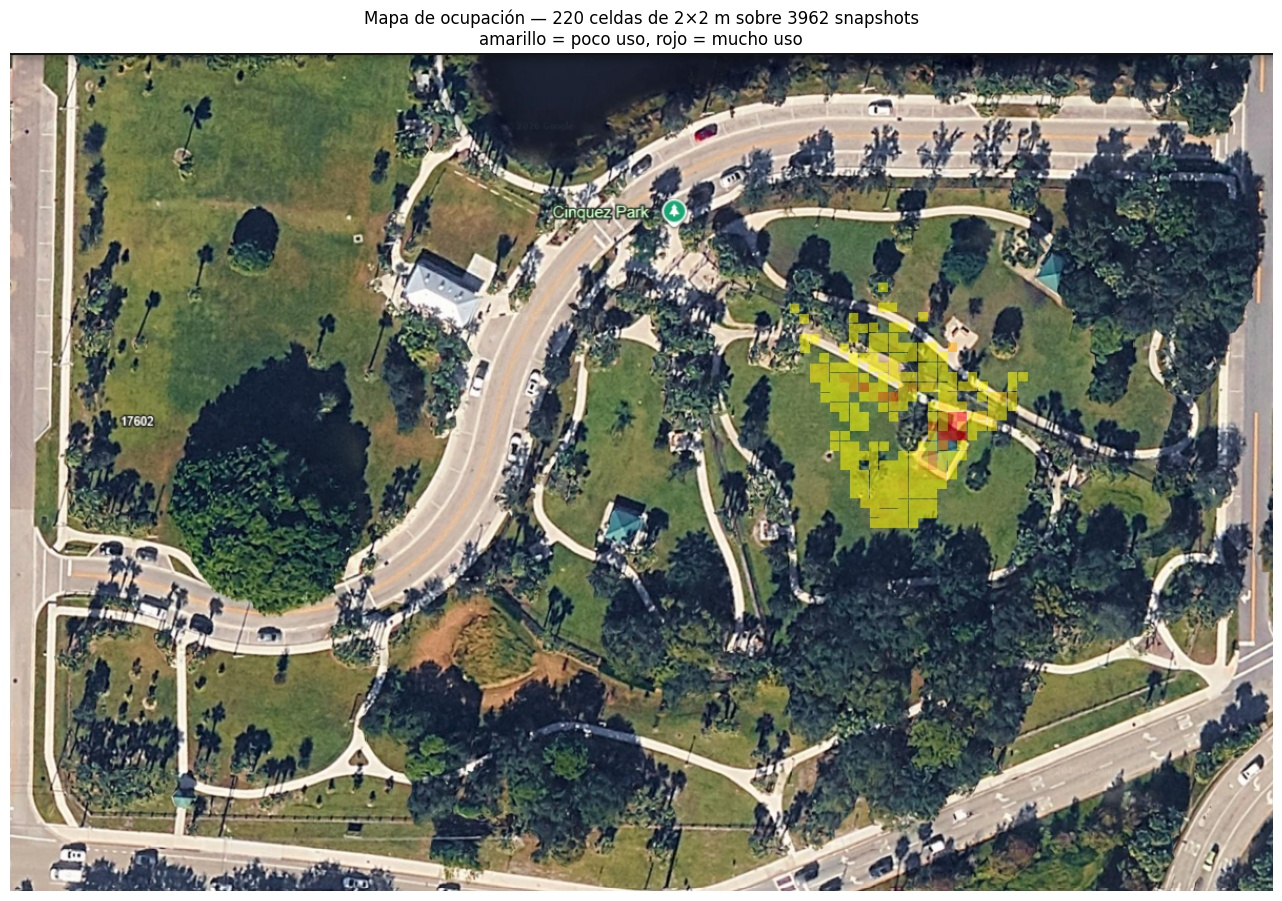

Celdas más usadas:
 centro_m_x  centro_m_y  n_personas  n_mascotas  n_total  cluster
      19.07       14.83         118          12      130        2
      19.07       10.83          93          37      130        2
      17.07       12.83          73          56      129        2
      17.07       10.83          80          33      113        2
      15.07       10.83          92          19      111        2


In [84]:
# ── Visualizar grilla de ocupación sobre el mapa satelital ───────────────────
if resultado_grilla is not None and len(resultado_grilla) > 0:
    sat_grilla = cv2.cvtColor(cv2.imread(RUTA_SATELITAL), cv2.COLOR_BGR2RGB).copy()
    overlay    = sat_grilla.copy()

    # escala: cuántos píxeles de satelital equivale 1 metro
    p0 = np.array(metros_a_satelital((0, 0), H_METROS_SAT), dtype=float)
    p1 = np.array(metros_a_satelital((1, 0), H_METROS_SAT), dtype=float)
    px_por_m = np.linalg.norm(p1 - p0)
    lado_px  = max(2, int(KMEANS_TAM_CELDA_M * px_por_m))

    max_uso = resultado_grilla['n_total'].max()
    for _, celda in resultado_grilla.iterrows():
        cx, cy = metros_a_satelital((celda['centro_m_x'], celda['centro_m_y']), H_METROS_SAT)
        intensidad = celda['n_total'] / max_uso
        # color: amarillo (poco uso) → rojo (mucho uso)
        color = (255, int(255*(1-intensidad)), 0)
        x1, y1 = cx - lado_px//2, cy - lado_px//2
        cv2.rectangle(overlay, (x1, y1), (x1+lado_px, y1+lado_px), color, -1)

    sat_grilla = cv2.addWeighted(overlay, 0.55, sat_grilla, 0.45, 0)

    plt.close('all')
    plt.figure(figsize=(13, 9))
    plt.imshow(sat_grilla)
    plt.title(f'Mapa de ocupación — {len(resultado_grilla)} celdas de '
              f'{KMEANS_TAM_CELDA_M}×{KMEANS_TAM_CELDA_M} m sobre {len(df_historico)} snapshots\n'
              f'amarillo = poco uso, rojo = mucho uso', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print('Celdas más usadas:')
    cols = ['centro_m_x','centro_m_y','n_personas','n_mascotas','n_total']
    if 'cluster' in resultado_grilla.columns:
        cols.append('cluster')
    print(resultado_grilla.nlargest(5, 'n_total')[cols].to_string(index=False))
else:
    print('Sin grilla para visualizar')

In [86]:
# ── #D: TESTS DE INVARIANTES ─────────────────────────────────────────────────
# Red de seguridad: verifica que las salidas del pipeline cumplen propiedades que
# SIEMPRE deben cumplirse. Sirve para detectar roturas silenciosas al cambiar
# umbrales o refactorizar (ej. al dividir en archivos .py).

def correr_tests():
    fallos = []
    def check(nombre, condicion, detalle=''):
        if condicion:
            print(f'  ✅ {nombre}')
        else:
            print(f'  ❌ {nombre}  {detalle}')
            fallos.append(nombre)

    print('=== TESTS DE INVARIANTES ===\n')

    print('MÁSCARAS:')
    check('máscara de suelo tiene shape de la imagen',
          MASCARA_SUELO.shape == (ALTO, ANCHO), f'{MASCARA_SUELO.shape}')
    check('máscara de suelo es binaria',
          set(np.unique(MASCARA_SUELO)) <= {0, 1})
    check('máscara de pasto tiene shape de la imagen',
          MASCARA_PASTO.shape == (ALTO, ANCHO))
    check('máscara de pasto es binaria',
          set(np.unique(MASCARA_PASTO)) <= {0, 1})
    check('máscara de sombra tiene shape de la imagen',
          mascara_sombra.shape == (ALTO, ANCHO))

    print('\nHOMOGRAFÍA:')
    check('H es 3x3', H_HOMOGRAFIA.shape == (3, 3))
    check('error mediano sub-métrico',
          stats_homografia['error_mediano'] < 2.0,
          f"{stats_homografia['error_mediano']} m")
    check('mayoría de puntos son inliers',
          stats_homografia['n_inliers'] >= stats_homografia['n_total'] * 0.7)
    check('área observada es positiva y plausible',
          0 < AREA_OBSERVADA_M2 < 100000, f'{AREA_OBSERVADA_M2} m²')
    # ida y vuelta: metros → satelital → metros debe dar (casi) lo mismo
    _p = (10.0, 10.0)
    _ida_vuelta = satelital_a_metros(metros_a_satelital(_p, H_METROS_SAT), H_METROS_SAT)
    check('ida y vuelta metros↔satelital es consistente',
          abs(_ida_vuelta[0]-_p[0]) < 0.5 and abs(_ida_vuelta[1]-_p[1]) < 0.5,
          f'{_p} → {_ida_vuelta}')

    print('\nRANGOS DE MÉTRICAS:')
    for campo in ['shade_util_personas', 'shade_util_mascotas', 'shade_parque_pct']:
        v = snapshot_record.get(campo)
        check(f'{campo} en [0,1] o None',
              v is None or 0.0 <= v <= 1.0, f'{v}')
    check('densidad no negativa',
          snapshot_record['densidad'] is None or snapshot_record['densidad'] >= 0)
    check('UTCI no es NaN',
          not np.isnan(snapshot_record['utci_valor']), f"{snapshot_record['utci_valor']}")
    check('categoría UTCI es del estándar',
          snapshot_record['utci_categoria'] in [c[1] for c in UTCI_CORTES])
    check('conteos no negativos',
          snapshot_record['n_personas'] >= 0 and snapshot_record['n_mascotas'] >= 0)

    print('\nCOHERENCIA DEL SNAPSHOT:')
    check('n_personas coincide con las posiciones guardadas',
          len(snapshot_record['pies_personas']) == snapshot_record['n_personas'])
    check('pos_m tiene misma longitud que pies',
          len(snapshot_record['pos_m_personas']) == len(snapshot_record['pies_personas']))
    check('campos del record coinciden con HEADERS',
          set(HEADERS) == set(snapshot_record.keys()),
          f'dif: {set(HEADERS) ^ set(snapshot_record.keys())}')
    check('shade_confiable implica condicion diurna',
          (not snapshot_record['shade_confiable']) or snapshot_record['condicion_luz'] == 'diurno')

    print('\nCASOS DE PRUEBA CON RESULTADO CONOCIDO:')
    # imagen negra → debe dar baja luz
    _negra = np.zeros((ALTO, ANCHO, 3), dtype=np.uint8)
    check('imagen negra → baja_luz',
          determinar_condicion_luz(_negra) == 'baja_luz')
    # lux alto real → diurno, sin mirar la imagen
    check('lux alto real → diurno',
          determinar_condicion_luz(_negra, lux=50000, lux_es_real=True) == 'diurno')
    # ExG de imagen verde pura debe ser alto; de gris, cercano a 0
    _verde = np.zeros((ALTO, ANCHO, 3), dtype=np.uint8); _verde[:, :, 1] = 255
    _gris  = np.full((ALTO, ANCHO, 3), 128, dtype=np.uint8)
    check('ExG de verde puro es alto',
          calcular_exg(_verde)['exg_prom'] > 1.0, f"{calcular_exg(_verde)['exg_prom']}")
    check('ExG de gris es ~0',
          abs(calcular_exg(_gris)['exg_prom']) < 0.05, f"{calcular_exg(_gris)['exg_prom']}")
    # detección fuera del rango confiable debe quedar sin pos_m
    _det_falsa = {'personas': [{'pie': (640, HORIZONTE_SUELO_Y + 1), 'bbox': (0,0,1,1)}],
                  'mascotas': []}
    _det_falsa = proyectar_detecciones(_det_falsa, H_HOMOGRAFIA)
    _p0 = _det_falsa['personas'][0]
    check('detección lejana se marca no confiable o dentro de rango',
          _p0['pos_m'] is None or _p0['pos_m_confiable'])

    print('\nMAPA DE CALOR UTCI (islas de calor por celda):')
    # solo se testea si el mapa se pudo calcular (guard: día con sombra)
    if resultado_mapa_calor is not None and len(resultado_mapa_calor) > 0:
        check('UTCI por celda no es NaN',
              not resultado_mapa_calor['utci_celda'].isna().any())
        check('categorías del mapa son del estándar UTCI',
              resultado_mapa_calor['utci_categoria'].isin(
                  [c[1] for c in UTCI_CORTES]).all())
        check('sombra_frac por celda en [0,1]',
              ((resultado_mapa_calor['sombra_frac'] >= 0) &
               (resultado_mapa_calor['sombra_frac'] <= 1)).all())
        check('mapa marcado como relativo (no medición absoluta)',
              resultado_mapa_calor.attrs.get('utci_celda_es_relativa') is True)
        # monotonía física: más sombra ⇒ UTCI no mayor (a igual snapshot)
        check('a más sombra, UTCI no aumenta (mrt_sol ≥ mrt_sombra)',
              resultado_mapa_calor.attrs['mrt_sol'] >= resultado_mapa_calor.attrs['mrt_sombra'])
    else:
        check('mapa de calor dormido es None (guard OK)',
              resultado_mapa_calor is None or len(resultado_mapa_calor) == 0)

    print(f'\n{"="*45}')
    if fallos:
        print(f'❌ {len(fallos)} test(s) fallaron: {fallos}')
    else:
        print('✅ Todos los tests pasaron')
    return fallos

fallos_tests = correr_tests()

=== TESTS DE INVARIANTES ===

MÁSCARAS:
  ✅ máscara de suelo tiene shape de la imagen
  ✅ máscara de suelo es binaria
  ✅ máscara de pasto tiene shape de la imagen
  ✅ máscara de pasto es binaria
  ✅ máscara de sombra tiene shape de la imagen

HOMOGRAFÍA:
  ✅ H es 3x3
  ✅ error mediano sub-métrico
  ✅ mayoría de puntos son inliers
  ✅ área observada es positiva y plausible
  ✅ ida y vuelta metros↔satelital es consistente

RANGOS DE MÉTRICAS:
  ✅ shade_util_personas en [0,1] o None
  ✅ shade_util_mascotas en [0,1] o None
  ✅ shade_parque_pct en [0,1] o None

... [3 líneas omitidas al aligerar el notebook para poder subirlo a GitHub] ...

  ✅ conteos no negativos

COHERENCIA DEL SNAPSHOT:
  ✅ n_personas coincide con las posiciones guardadas
  ✅ pos_m tiene misma longitud que pies
  ✅ campos del record coinciden con HEADERS
  ✅ shade_confiable implica condicion diurna

CASOS DE PRUEBA CON RESULTADO CONOCIDO:
  ✅ imagen negra → baja_luz
  ✅ lux alto real → diurno
  ✅ ExG de verde puro es a